<a href="https://colab.research.google.com/github/arnavon2005/Army_Provost_ML_Project/blob/main/05_Machine_Learning_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Model Development

> **Project:** Army Provost Machine Learning Project  
> **Dataset:** Chicago Crimes Dataset  
> **Notebook:** 05_Machine_Learning_Modeling.ipynb

## Objective

This notebook focuses on developing and evaluating machine learning models for crime analysis.

The primary objective is to build a predictive model that estimates whether a reported crime incident is likely to result in an arrest.

The notebook includes:

- Dataset Loading
- Feature Engineering
- Feature Selection
- Feature Encoding
- Model Training
- Model Evaluation
- Model Comparison
- Model Saving

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

# Models

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_PATH = Path("/content/drive/MyDrive/Army_Provost_ML_Project")

DATA_PATH = PROJECT_PATH / "Datasets"

RAW_DATASET_PATH = DATA_PATH / "Raw"
CLEAN_DATASET_PATH = DATA_PATH / "Cleaned"

FIGURES_PATH = PROJECT_PATH / "Figures"
REPORTS_PATH = PROJECT_PATH / "Reports"
MODELS_PATH = PROJECT_PATH / "Models"
OUTPUTS_PATH = PROJECT_PATH / "Outputs"
LOGS_PATH = PROJECT_PATH / "Logs"

# Create folders if they don't exist
for folder in [
    FIGURES_PATH,
    REPORTS_PATH,
    MODELS_PATH,
    OUTPUTS_PATH,
    LOGS_PATH
]:
    folder.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("Project directories configured successfully.")
print("=" * 70)
print(f"Project : {PROJECT_PATH}")
print(f"Cleaned Data : {CLEAN_DATASET_PATH}")
print(f"Models : {MODELS_PATH}")
print(f"Figures : {FIGURES_PATH}")
print("=" * 70)

Project directories configured successfully.
Project : /content/drive/MyDrive/Army_Provost_ML_Project
Cleaned Data : /content/drive/MyDrive/Army_Provost_ML_Project/Datasets/Cleaned
Models : /content/drive/MyDrive/Army_Provost_ML_Project/Models
Figures : /content/drive/MyDrive/Army_Provost_ML_Project/Figures


In [4]:
# ============================================================
# Load Cleaned Dataset
# ============================================================

print("=" * 70)
print("Loading Cleaned Dataset")
print("=" * 70)

chicago_df = pd.read_csv(
    CLEAN_DATASET_PATH / "chicago_crimes_cleaned.csv",
    low_memory=False
)

print("\nDataset Loaded Successfully!\n")

print(f"Shape : {chicago_df.shape}")

display(chicago_df.head())

Loading Cleaned Dataset

Dataset Loaded Successfully!

Shape : (8602734, 22)


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14269678,JK342166,2026-07-20 00:00:00,001XX E WACKER DR,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,HOTEL / MOTEL,False,False,...,42.0,32.0,02,1177683.0,1902638.0,2026,2026-07-27 15:43:52,41.888165,-87.622940,"(41.888165132, -87.622937212)"
1,14267487,JK340097,2026-07-20 00:00:00,084XX S MARYLAND AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,...,8.0,44.0,14,1183361.0,1849252.0,2026,2026-07-27 15:43:52,41.741540,-87.603750,"(41.741539131, -87.603750482)"
2,14267485,JK340089,2026-07-20 00:00:00,105XX S WABASH AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,9.0,49.0,08B,1178438.0,1835166.0,2026,2026-07-27 15:43:52,41.703000,-87.622215,"(41.70299844, -87.622214313)"
3,14268664,JK341413,2026-07-20 00:00:00,091XX S LAFAYETTE AVE,0810,THEFT,OVER $500,RESIDENCE,False,True,...,9.0,49.0,06,1177542.0,1844332.0,2026,2026-07-27 15:43:52,41.728172,-87.625220,"(41.728171435, -87.625219193)"
4,14269513,JK342626,2026-07-20 00:00:00,028XX N KIMBALL AVE,4387,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,APARTMENT,False,False,...,35.0,21.0,26,1153219.0,1919032.0,2026,2026-07-27 15:43:52,41.933674,-87.712340,"(41.933672358, -87.712341606)"


# ============================================================
# Feature Engineering
# ============================================================

## Objective

The objective of this phase is to prepare the dataset for machine learning by
selecting appropriate predictor variables, creating useful time-based features,
and removing columns that are either identifiers, redundant, or could introduce
data leakage.

Proper feature engineering is one of the most important stages of any machine
learning project because the quality of the input features directly affects the
performance and generalization ability of the final model.

## Why is Feature Engineering Important?

Machine learning algorithms cannot automatically determine which columns are
useful and which may negatively affect prediction performance.

During this phase we will:

- Select the target variable.
- Select predictor variables.
- Remove identifier and leakage columns.
- Verify data types.
- Prepare the dataset for encoding.

This step ensures that the model learns meaningful crime patterns instead of
memorizing record-specific information.

## Expected Outcome

By the end of this section we will have a clean feature matrix (X) and target
variable (y) ready for preprocessing and encoding.

## Extracting Time-Based Features

The original dataset contains a `Date` column with both date and time information.
Many machine learning algorithms benefit from explicit temporal features rather than
a single timestamp.

In this step, we convert the `Date` column to a datetime object (if required) and
derive the following features:

- Month
- Day
- Hour

These features will be used as predictor variables in later stages of the project.

In [5]:
# ============================================================
# Extract Time-Based Features
# ============================================================

print("=" * 70)
print("Creating Time-Based Features")
print("=" * 70)

# Convert Date column to datetime (safe even if already converted)
chicago_df["Date"] = pd.to_datetime(chicago_df["Date"])

# Extract temporal features
chicago_df["Month"] = chicago_df["Date"].dt.month
chicago_df["Day"] = chicago_df["Date"].dt.day
chicago_df["Hour"] = chicago_df["Date"].dt.hour

print("\nTime-based features created successfully.")

print("\nNew Columns Added:")
print(["Month", "Day", "Hour"])

print("\nPreview:")
print(chicago_df[["Date", "Month", "Day", "Hour"]].head())

Creating Time-Based Features

Time-based features created successfully.

New Columns Added:
['Month', 'Day', 'Hour']

Preview:
        Date  Month  Day  Hour
0 2026-07-20      7   20     0
1 2026-07-20      7   20     0
2 2026-07-20      7   20     0
3 2026-07-20      7   20     0
4 2026-07-20      7   20     0


In [6]:
# ============================================================
# Feature Engineering
# ============================================================

print("=" * 70)
print("Feature Engineering")
print("=" * 70)

# -----------------------------
# Target Variable
# -----------------------------
TARGET_COLUMN = "Arrest"

# -----------------------------
# Selected Predictor Columns
# -----------------------------
FEATURE_COLUMNS = [
    "Primary Type",
    "Description",
    "Location Description",
    "Domestic",
    "Year",
    "Month",
    "Day",
    "Hour",
    "District",
    "Beat",
    "Ward",
    "Community Area"
]

# -----------------------------
# Create Feature Matrix & Target
# -----------------------------
X = chicago_df[FEATURE_COLUMNS].copy()
y = chicago_df[TARGET_COLUMN].copy()

print(f"\nTarget Variable : {TARGET_COLUMN}")
print(f"Number of Features : {len(FEATURE_COLUMNS)}")

print("\nSelected Features:")
for i, feature in enumerate(FEATURE_COLUMNS, start=1):
    print(f"{i:>2}. {feature}")

print("\nFeature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

Feature Engineering

Target Variable : Arrest
Number of Features : 12

Selected Features:
 1. Primary Type
 2. Description
 3. Location Description
 4. Domestic
 5. Year
 6. Month
 7. Day
 8. Hour
 9. District
10. Beat
11. Ward
12. Community Area

Feature Matrix Shape : (8602734, 12)
Target Shape         : (8602734,)


## Feature Validation

Before applying encoding and training machine learning models, it is important to
validate the selected predictor variables.

During this step we will:

- Verify the data types of all selected features.
- Check for missing values.
- Ensure the target variable contains valid binary classes.

This validation helps prevent errors during preprocessing and model training while
maintaining a reliable and reproducible machine learning pipeline.

In [7]:
# ============================================================
# Feature Validation
# ============================================================

print("=" * 70)
print("Feature Validation")
print("=" * 70)

# Display feature data types
print("\nFeature Data Types:\n")
print(X.dtypes)

# Missing values
missing_summary = (
    X.isnull()
     .sum()
     .to_frame(name="Missing Values")
)

missing_summary["Percentage"] = (
    missing_summary["Missing Values"] / len(X) * 100
).round(2)

print("\n")
print("=" * 70)
print("Missing Value Summary")
print("=" * 70)

print(missing_summary)

print("\n")
print("=" * 70)
print("Target Distribution")
print("=" * 70)

print(y.value_counts())

print("\n")
print("Target Percentage:")

print(
    (y.value_counts(normalize=True) * 100)
    .round(2)
)

Feature Validation

Feature Data Types:

Primary Type             object
Description              object
Location Description     object
Domestic                   bool
Year                      int64
Month                     int32
Day                       int32
Hour                      int32
District                float64
Beat                      int64
Ward                    float64
Community Area          float64
dtype: object


Missing Value Summary
                      Missing Values  Percentage
Primary Type                       0        0.00
Description                        0        0.00
Location Description               0        0.00
Domestic                           0        0.00
Year                               0        0.00
Month                              0        0.00
Day                                0        0.00
Hour                               0        0.00
District                          47        0.00
Beat                               0        0.0

# ============================================================
# Missing Value Treatment
# ============================================================

## Objective

Before applying categorical encoding and training machine learning models, all
selected predictor variables should be free from missing values.

Machine learning algorithms generally do not handle missing values consistently,
and preprocessing techniques such as one-hot encoding require complete data.

In this step, missing values are imputed using the most frequent (mode) value
for each feature. This approach preserves all observations while maintaining
the categorical nature of geographical variables.

## Imputation Strategy

| Feature | Strategy |
|----------|----------|
| District | Mode |
| Ward | Mode |
| Community Area | Mode |

## Expected Outcome

After this step, the feature matrix will contain no missing values and will be
ready for categorical encoding.

In [8]:
# ============================================================
# Missing Value Treatment
# ============================================================

print("=" * 70)
print("Missing Value Treatment")
print("=" * 70)

# Store missing values before imputation
missing_before = X.isnull().sum()

print("\nMissing Values Before Imputation:\n")
print(missing_before[missing_before > 0])

# ------------------------------------------------------------
# Mode Imputation
# ------------------------------------------------------------

imputation_columns = [
    "District",
    "Ward",
    "Community Area"
]

for column in imputation_columns:
    mode_value = X[column].mode()[0]
    X[column] = X[column].fillna(mode_value)

# ------------------------------------------------------------
# Verify Imputation
# ------------------------------------------------------------

missing_after = X.isnull().sum()

print("\n")
print("=" * 70)
print("Missing Values After Imputation")
print("=" * 70)

print(missing_after[missing_after > 0])

if missing_after.sum() == 0:
    print("\n✅ All missing values have been successfully handled.")
else:
    print("\n⚠️ Some missing values are still present.")

print("\nFinal Dataset Shape:", X.shape)

Missing Value Treatment

Missing Values Before Imputation:

District              47
Ward              614813
Community Area    613724
dtype: int64


Missing Values After Imputation
Series([], dtype: int64)

✅ All missing values have been successfully handled.

Final Dataset Shape: (8602734, 12)


# ============================================================
# Categorical Feature Analysis
# ============================================================

## Objective

Before applying categorical encoding, it is important to understand the
cardinality of each categorical feature.

The number of unique values directly influences the choice of encoding
technique, memory consumption, and model training time.

This analysis will help determine the most appropriate encoding strategy for
each categorical variable.

In [ ]:
# ============================================================
# Categorical Feature Analysis
# ============================================================

print("=" * 70)
print("Categorical Feature Analysis")
print("=" * 70)

categorical_columns = [
    "Primary Type",
    "Description",
    "Location Description"
]

summary = []

for column in categorical_columns:
    unique_count = X[column].nunique()

    summary.append({
        "Feature": column,
        "Unique Values": unique_count
    })

summary_df = pd.DataFrame(summary)

print(summary_df)

print("\n")

for column in categorical_columns:
    print("-" * 70)
    print(column)
    print("-" * 70)
    print(X[column].value_counts().head(10))
    print()

Categorical Feature Analysis
                Feature  Unique Values
0          Primary Type             34
1           Description            570
2  Location Description            219


----------------------------------------------------------------------
Primary Type
----------------------------------------------------------------------
Primary Type
THEFT                  1827377
BATTERY                1567212
CRIMINAL DAMAGE         977357
NARCOTICS               768704
ASSAULT                 580094
OTHER OFFENSE           537540
BURGLARY                455436
MOTOR VEHICLE THEFT     444725
DECEPTIVE PRACTICE      400071
ROBBERY                 318103
Name: count, dtype: int64

----------------------------------------------------------------------
Description
----------------------------------------------------------------------
Description
SIMPLE                          1012886
$500 AND UNDER                   687475
DOMESTIC BATTERY SIMPLE          672476
TO VEHICLE            

# ============================================================
# Preprocessing Pipeline
# ============================================================

## Objective

Machine learning models require numerical input data. Since the dataset contains
both categorical and numerical features, an appropriate preprocessing pipeline
must be constructed.

In this section, we:

- Remove the high-cardinality `Description` feature.
- Separate categorical and numerical features.
- Apply One-Hot Encoding to categorical variables.
- Pass numerical variables through without modification.
- Build a reusable preprocessing pipeline using Scikit-learn's
  `ColumnTransformer`.

Using a preprocessing pipeline improves reproducibility, prevents data leakage,
and ensures that the same transformations are applied during both training and
future predictions.

## Expected Outcome

A reusable preprocessing pipeline ready for train-test splitting and model
training.

In [9]:
# ============================================================
# Preprocessing Pipeline
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

print("=" * 70)
print("Building Preprocessing Pipeline")
print("=" * 70)

# ------------------------------------------------------------
# Remove High-Cardinality Feature
# ------------------------------------------------------------

X = X.drop(columns=["Description"])

print("\nRemoved Feature:")
print("Description")

# ------------------------------------------------------------
# Define Feature Groups
# ------------------------------------------------------------

categorical_features = [
    "Primary Type",
    "Location Description",
    "Domestic"
]

numerical_features = [
    "Year",
    "Month",
    "Day",
    "Hour",
    "District",
    "Beat",
    "Ward",
    "Community Area"
]

print("\nCategorical Features:")
for feature in categorical_features:
    print(f"• {feature}")

print("\nNumerical Features:")
for feature in numerical_features:
    print(f"• {feature}")

# ------------------------------------------------------------
# Build ColumnTransformer
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("\n✅ Preprocessing pipeline created successfully.")

print("\nTotal Features Remaining:", X.shape[1])

Building Preprocessing Pipeline

Removed Feature:
Description

Categorical Features:
• Primary Type
• Location Description
• Domestic

Numerical Features:
• Year
• Month
• Day
• Hour
• District
• Beat
• Ward
• Community Area

✅ Preprocessing pipeline created successfully.

Total Features Remaining: 11


# ============================================================
# Stratified Sampling
# ============================================================

## Objective

The original dataset contains over 8.6 million crime records. Training multiple
machine learning models directly on the entire dataset during development would
require significant computational resources and considerably increase execution
time.

To build, validate, and compare models efficiently, a representative stratified
sample is created while preserving the original class distribution of the target
variable (`Arrest`).

## Why Stratified Sampling?

- Preserves the proportion of arrest and non-arrest cases.
- Reduces training time and memory consumption.
- Enables rapid experimentation and debugging.
- Provides a scalable workflow that can later be applied to the complete dataset.

## Sampling Fraction

A 20% stratified sample is used for model development.

The complete dataset will be used later for final large-scale model training and
performance evaluation.

In [10]:
# ============================================================
# Stratified Sampling
# ============================================================

from sklearn.model_selection import train_test_split

print("=" * 70)
print("Creating Stratified Sample")
print("=" * 70)

SAMPLE_SIZE = 0.20
RANDOM_STATE = 42

# ------------------------------------------------------------
# Create Stratified Sample
# ------------------------------------------------------------

X_sample, _, y_sample, _ = train_test_split(
    X,
    y,
    train_size=SAMPLE_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"\nOriginal Dataset Size : {len(X):,}")
print(f"Sample Dataset Size   : {len(X_sample):,}")

print("\nTarget Distribution (Original):")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nTarget Distribution (Sample):")
print((y_sample.value_counts(normalize=True) * 100).round(2))

Creating Stratified Sample

Original Dataset Size : 8,602,734
Sample Dataset Size   : 1,720,546

Target Distribution (Original):
Arrest
False    74.97
True     25.03
Name: proportion, dtype: float64

Target Distribution (Sample):
Arrest
False    74.97
True     25.03
Name: proportion, dtype: float64


# ============================================================
# Train-Test Split
# ============================================================

## Objective

Before training machine learning models, the sampled dataset is divided into
training and testing subsets.

The training dataset is used to fit the preprocessing pipeline and train the
machine learning models.

The testing dataset remains completely unseen during training and is used only
for evaluating model performance.

A stratified split is performed to preserve the original class distribution of
the target variable (`Arrest`) in both subsets.

## Split Ratio

- Training Set: 80%
- Testing Set: 20%

## Expected Outcome

Two independent datasets that can be used for unbiased model training and
evaluation.

In [11]:
# ============================================================
# Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

print("=" * 70)
print("Creating Train-Test Split")
print("=" * 70)

TEST_SIZE = 0.20
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X_sample,
    y_sample,
    test_size=TEST_SIZE,
    stratify=y_sample,
    random_state=RANDOM_STATE
)

print(f"\nTraining Samples : {len(X_train):,}")
print(f"Testing Samples  : {len(X_test):,}")

print("\nTraining Target Distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Target Distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Creating Train-Test Split

Training Samples : 1,376,436
Testing Samples  : 344,110

Training Target Distribution:
Arrest
False    74.97
True     25.03
Name: proportion, dtype: float64

Testing Target Distribution:
Arrest
False    74.97
True     25.03
Name: proportion, dtype: float64


# ============================================================
# Fit and Apply Preprocessing Pipeline
# ============================================================

## Objective

The preprocessing pipeline is fitted using only the training dataset to prevent
data leakage.

Once fitted, the same learned transformations are applied to both the training
and testing datasets.

This ensures that the model has no prior knowledge of the testing data during
training while maintaining consistent feature engineering across both datasets.

## Why is this Important?

Fitting preprocessing steps on the entire dataset would expose information from
the testing set to the model, resulting in overly optimistic performance
estimates.

By fitting only on the training data, we ensure a fair and realistic evaluation
of the machine learning models.

## Expected Outcome

- Fitted preprocessing pipeline
- Encoded training feature matrix
- Encoded testing feature matrix
- Final feature dimensions after encoding

In [12]:
# ============================================================
# Fit and Apply Preprocessing Pipeline
# ============================================================

print("=" * 70)
print("Applying Preprocessing Pipeline")
print("=" * 70)

# ------------------------------------------------------------
# Fit only on training data
# ------------------------------------------------------------

print("\nFitting preprocessor on training data...")
preprocessor.fit(X_train)

# ------------------------------------------------------------
# Transform datasets
# ------------------------------------------------------------

print("Transforming training dataset...")
X_train_processed = preprocessor.transform(X_train)

print("Transforming testing dataset...")
X_test_processed = preprocessor.transform(X_test)

# ------------------------------------------------------------
# Display Results
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("Preprocessing Complete")
print("=" * 70)

print(f"\nTraining Shape After Encoding : {X_train_processed.shape}")
print(f"Testing Shape After Encoding  : {X_test_processed.shape}")

print(f"\nTotal Engineered Features : {X_train_processed.shape[1]}")

Applying Preprocessing Pipeline

Fitting preprocessor on training data...
Transforming training dataset...
Transforming testing dataset...


Preprocessing Complete

Training Shape After Encoding : (1376436, 231)
Testing Shape After Encoding  : (344110, 231)

Total Engineered Features : 231


# ============================================================
# Logistic Regression Preprocessing Pipeline
# ============================================================

## Objective

Logistic Regression performs best when numerical features are standardized.
Therefore, a dedicated preprocessing pipeline is created for this model.

The pipeline performs:

- One-Hot Encoding for categorical variables.
- Standardization of numerical variables.
- Prevention of data leakage by fitting only on the training dataset.

Tree-based models will continue using the previously created preprocessing
pipeline without feature scaling.

## Why Standardization?

Standardizing numerical features improves optimization, accelerates model
convergence, and prevents variables with larger numeric ranges from dominating
the learning process.

Since One-Hot Encoding produces a sparse feature matrix, the StandardScaler is
configured with `with_mean=False` to preserve sparsity and reduce memory usage.

In [ ]:
# ============================================================
# Logistic Regression Preprocessing Pipeline
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("=" * 70)
print("Building Logistic Regression Preprocessing Pipeline")
print("=" * 70)

# ------------------------------------------------------------
# Create Logistic Regression Preprocessor
# ------------------------------------------------------------

lr_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        ),
        (
            "numerical",
            Pipeline([
                ("scaler", StandardScaler())
            ]),
            numerical_features
        )
    ]
)

print("\nFitting Logistic Regression preprocessor...")

X_train_lr = lr_preprocessor.fit_transform(X_train)
X_test_lr = lr_preprocessor.transform(X_test)

print("\n")
print("=" * 70)
print("Pipeline Ready")
print("=" * 70)

print(f"\nTraining Shape : {X_train_lr.shape}")
print(f"Testing Shape  : {X_test_lr.shape}")

Building Logistic Regression Preprocessing Pipeline

Fitting Logistic Regression preprocessor...


Pipeline Ready

Training Shape : (1376436, 231)
Testing Shape  : (344110, 231)


# ============================================================
# Baseline Model - Logistic Regression
# ============================================================

## Objective

The first machine learning model developed in this project is Logistic
Regression.

Logistic Regression is a widely used linear classification algorithm and serves
as an effective baseline model for binary classification tasks.

To address the moderate class imbalance present in the dataset, balanced class
weights are used during training.

## Why Logistic Regression?

- Fast to train
- Highly interpretable
- Strong baseline for binary classification
- Provides probability estimates
- Serves as a benchmark for more complex models

## Model Configuration

- Solver: lbfgs
- Maximum Iterations: 500
- Class Weight: balanced
- Random State: 42

In [ ]:
# ============================================================
# Logistic Regression Model Training
# ============================================================

import time

from sklearn.linear_model import LogisticRegression

print("=" * 70)
print("Training Logistic Regression Model")
print("=" * 70)

start_time = time.time()

# ------------------------------------------------------------
# Create Model
# ------------------------------------------------------------

lr_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=500,
    solver="lbfgs"
)

# ------------------------------------------------------------
# Train Model
# ------------------------------------------------------------

lr_model.fit(X_train_lr, y_train)

training_time = time.time() - start_time

print("\nTraining Completed Successfully!")

print(f"\nTraining Time : {training_time:.2f} seconds")

Training Logistic Regression Model

Training Completed Successfully!

Training Time : 20.69 seconds


# ============================================================
# Logistic Regression Model Evaluation
# ============================================================

## Objective

After training the Logistic Regression model, its predictive performance is
evaluated using multiple classification metrics.

Since the dataset is moderately imbalanced, relying only on accuracy may be
misleading. Therefore, additional metrics such as Precision, Recall, F1-Score,
and ROC-AUC are also computed.

The evaluation also includes the Confusion Matrix and Classification Report to
provide a detailed understanding of the model's strengths and weaknesses.

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix
- Classification Report
- Prediction Time

## Expected Outcome

A comprehensive baseline performance assessment that will be used for comparison
with more advanced machine learning models.

Evaluating Logistic Regression Model

Accuracy        : 0.8301
Precision       : 0.6539
Recall          : 0.6824
F1 Score        : 0.6678
ROC-AUC Score   : 0.8748
Prediction Time : 0.05 seconds


Classification Report
              precision    recall  f1-score   support

       False       0.89      0.88      0.89    257971
        True       0.65      0.68      0.67     86139

    accuracy                           0.83    344110
   macro avg       0.77      0.78      0.78    344110
weighted avg       0.83      0.83      0.83    344110



<Figure size 600x500 with 0 Axes>

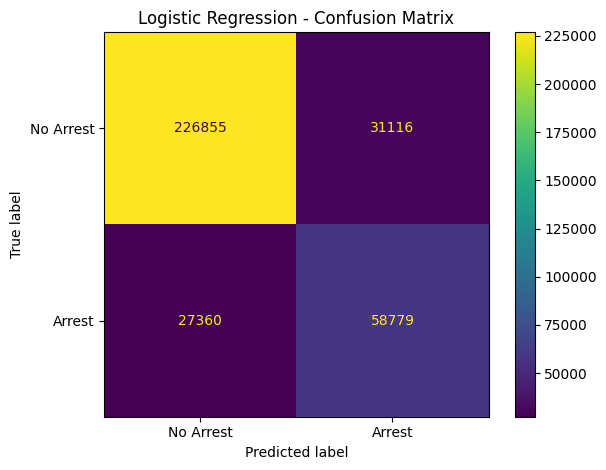

In [ ]:
# ============================================================
# Logistic Regression Model Evaluation
# ============================================================

import time

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("=" * 70)
print("Evaluating Logistic Regression Model")
print("=" * 70)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

start_time = time.time()

y_pred = lr_model.predict(X_test_lr)
y_prob = lr_model.predict_proba(X_test_lr)[:, 1]

prediction_time = time.time() - start_time

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"\nAccuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1 Score        : {f1:.4f}")
print(f"ROC-AUC Score   : {roc_auc:.4f}")
print(f"Prediction Time : {prediction_time:.2f} seconds")

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("Classification Report")
print("=" * 70)

print(classification_report(y_test, y_pred))

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Arrest", "Arrest"]
).plot(values_format="d")

plt.title("Logistic Regression - Confusion Matrix")

plt.tight_layout()

plt.show()

# ============================================================
# Model Performance Tracking
# ============================================================

## Objective

To facilitate systematic comparison of multiple machine learning models, a
centralized results table is created.

After evaluating each model, its performance metrics and execution time will be
stored in this table.

This approach enables an objective comparison between models and helps identify
the best-performing classifier for the crime prediction task.

## Metrics Recorded

- Model Name
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Training Time
- Prediction Time

## Expected Outcome

A consolidated performance table that will be updated after each model is
evaluated.

In [ ]:
# ============================================================
# Model Performance Tracking
# ============================================================

import pandas as pd

print("=" * 70)
print("Initializing Model Performance Tracker")
print("=" * 70)

# ------------------------------------------------------------
# Create Results List
# ------------------------------------------------------------

model_results = []

# ------------------------------------------------------------
# Store Logistic Regression Results
# ------------------------------------------------------------

model_results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc,
    "Training Time (s)": training_time,
    "Prediction Time (s)": prediction_time
})

# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

results_df = pd.DataFrame(model_results)

# Format numeric values for display
display_df = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "Training Time (s)",
    "Prediction Time (s)"
]

display_df[metric_columns] = display_df[metric_columns].round(4)

print("\nCurrent Model Comparison:\n")
print(display_df)

Initializing Model Performance Tracker

Current Model Comparison:

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  \
0  Logistic Regression    0.8301     0.6539  0.6824    0.6678   0.8748   

   Training Time (s)  Prediction Time (s)  
0            20.6913               0.0463  


# ============================================================
# Random Forest Classifier
# ============================================================

## Objective

The Random Forest Classifier is an ensemble learning algorithm that combines
multiple decision trees to improve predictive performance and reduce overfitting.

Unlike Logistic Regression, Random Forest can capture complex nonlinear
relationships and interactions among features without requiring feature scaling.

To establish a computationally efficient baseline, the model is initially trained
with 50 decision trees and a maximum depth of 20.

If Random Forest demonstrates superior performance, additional hyperparameter
tuning will be performed later in the project.

## Model Configuration

- Number of Trees: 50
- Maximum Tree Depth: 20
- Class Weight: balanced_subsample
- Random State: 42
- Parallel Processing: Enabled

In [ ]:
# ============================================================
# Random Forest Model Training
# ============================================================

import time

from sklearn.ensemble import RandomForestClassifier

print("=" * 70)
print("Training Random Forest Classifier")
print("=" * 70)

start_time = time.time()

# ------------------------------------------------------------
# Create Model
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Train Model
# ------------------------------------------------------------

rf_model.fit(X_train_processed, y_train)

rf_training_time = time.time() - start_time

print("\nTraining Completed Successfully!")

print(f"\nTraining Time : {rf_training_time:.2f} seconds")

Training Random Forest Classifier

Training Completed Successfully!

Training Time : 719.50 seconds


# ============================================================
# Random Forest Model Evaluation
# ============================================================

## Objective

The trained Random Forest model is evaluated using multiple classification
metrics to assess its predictive performance.

The same evaluation methodology used for Logistic Regression is applied here,
allowing an objective comparison between the two models.

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix
- Classification Report
- Prediction Time

## Expected Outcome

A detailed assessment of the Random Forest model that will be added to the
overall model comparison table.

Evaluating Random Forest Classifier

Accuracy        : 0.8672
Precision       : 0.7733
Recall          : 0.6640
F1 Score        : 0.7145
ROC-AUC Score   : 0.8882
Prediction Time : 9.77 seconds


Classification Report
              precision    recall  f1-score   support

       False       0.89      0.94      0.91    257971
        True       0.77      0.66      0.71     86139

    accuracy                           0.87    344110
   macro avg       0.83      0.80      0.81    344110
weighted avg       0.86      0.87      0.86    344110



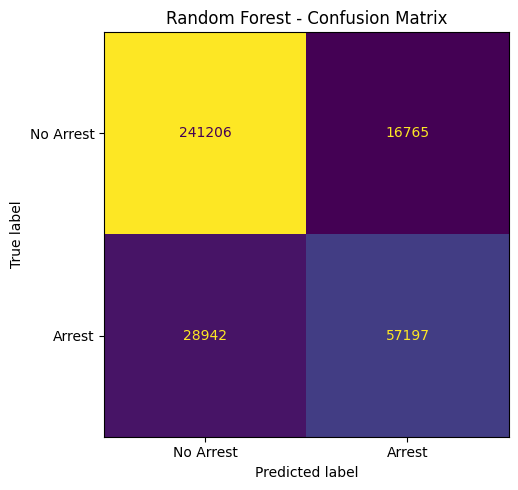

In [ ]:
# ============================================================
# Random Forest Model Evaluation
# ============================================================

import time

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("=" * 70)
print("Evaluating Random Forest Classifier")
print("=" * 70)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

start_time = time.time()

rf_pred = rf_model.predict(X_test_processed)
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

rf_prediction_time = time.time() - start_time

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print(f"\nAccuracy        : {rf_accuracy:.4f}")
print(f"Precision       : {rf_precision:.4f}")
print(f"Recall          : {rf_recall:.4f}")
print(f"F1 Score        : {rf_f1:.4f}")
print(f"ROC-AUC Score   : {rf_roc_auc:.4f}")
print(f"Prediction Time : {rf_prediction_time:.2f} seconds")

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("Classification Report")
print("=" * 70)

print(classification_report(y_test, rf_pred))

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Arrest", "Arrest"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d", colorbar=False)

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Update Model Comparison Table
# ============================================================

model_results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "ROC-AUC": rf_roc_auc,
    "Training Time (s)": rf_training_time,
    "Prediction Time (s)": rf_prediction_time
})

results_df = pd.DataFrame(model_results)

display_df = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "Training Time (s)",
    "Prediction Time (s)"
]

display_df[metric_columns] = display_df[metric_columns].round(4)

print("\nCurrent Model Comparison:\n")
print(display_df)


Current Model Comparison:

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  \
0  Logistic Regression    0.8301     0.6539  0.6824    0.6678   0.8748   
1        Random Forest    0.8672     0.7733  0.6640    0.7145   0.8882   

   Training Time (s)  Prediction Time (s)  
0            20.6913               0.0463  
1           719.4961               9.7686  


# ============================================================
# Installing CatBoost
# ============================================================

## Objective

CatBoost is a gradient boosting algorithm specifically designed for structured
(tabular) datasets containing both categorical and numerical features.

Unlike many other boosting algorithms, CatBoost can efficiently process
categorical variables while providing excellent predictive performance.

The library is installed in the Google Colab environment before training the
final boosting model.

In [ ]:
# ============================================================
# Install CatBoost
# ============================================================

!pip install -q catboost

print("✅ CatBoost Installed Successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.8 MB/s eta 0:00:00
✅ CatBoost Installed Successfully


# ============================================================
# CatBoost Classifier
# ============================================================

## Objective

The CatBoost Classifier is trained as the third machine learning model in this
study.

CatBoost is a gradient boosting algorithm specifically designed for structured
datasets and is particularly effective when working with categorical variables.

Compared with Random Forest, CatBoost builds trees sequentially, allowing each
new tree to correct the errors made by previous trees.

## Model Configuration

- Iterations: 300
- Learning Rate: 0.1
- Tree Depth: 8
- Evaluation Metric: AUC
- Random State: 42

In [ ]:
# ============================================================
# Train CatBoost Classifier
# ============================================================

import time
from catboost import CatBoostClassifier

print("=" * 70)
print("Training CatBoost Classifier")
print("=" * 70)

start_time = time.time()

# ------------------------------------------------------------
# Identify categorical feature indices
# ------------------------------------------------------------

cat_features = [
    X_train.columns.get_loc(col)
    for col in categorical_features
]

# ------------------------------------------------------------
# Create Model
# ------------------------------------------------------------

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=8,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=50
)

# ------------------------------------------------------------
# Train Model
# ------------------------------------------------------------

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

cat_training_time = time.time() - start_time

print("\n")
print("=" * 70)
print("Training Completed Successfully")
print("=" * 70)

print(f"\nTraining Time : {cat_training_time:.2f} seconds")

Training CatBoost Classifier
0:	total: 2.01s	remaining: 10m
50:	total: 1m 18s	remaining: 6m 25s
100:	total: 2m 48s	remaining: 5m 32s
150:	total: 4m 14s	remaining: 4m 10s
200:	total: 5m 48s	remaining: 2m 51s
250:	total: 7m 16s	remaining: 1m 25s
299:	total: 8m 44s	remaining: 0us


Training Completed Successfully

Training Time : 539.74 seconds


Evaluating CatBoost Classifier

Accuracy        : 0.8838
Precision       : 0.8955
Recall          : 0.6065
F1 Score        : 0.7232
ROC-AUC Score   : 0.8981
Prediction Time : 15.25 seconds


Classification Report
              precision    recall  f1-score   support

       False       0.88      0.98      0.93    257971
        True       0.90      0.61      0.72     86139

    accuracy                           0.88    344110
   macro avg       0.89      0.79      0.82    344110
weighted avg       0.88      0.88      0.88    344110



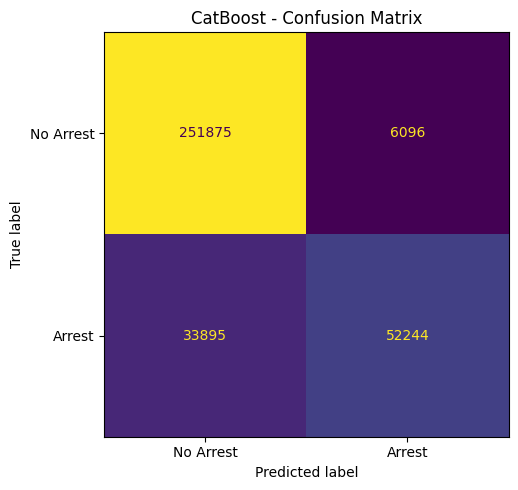

In [ ]:
# ============================================================
# Evaluate CatBoost Classifier
# ============================================================

import time
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("=" * 70)
print("Evaluating CatBoost Classifier")
print("=" * 70)

start_time = time.time()

cat_pred = cat_model.predict(X_test)
cat_prob = cat_model.predict_proba(X_test)[:, 1]

cat_prediction_time = time.time() - start_time

cat_accuracy = accuracy_score(y_test, cat_pred)
cat_precision = precision_score(y_test, cat_pred)
cat_recall = recall_score(y_test, cat_pred)
cat_f1 = f1_score(y_test, cat_pred)
cat_roc_auc = roc_auc_score(y_test, cat_prob)

print(f"\nAccuracy        : {cat_accuracy:.4f}")
print(f"Precision       : {cat_precision:.4f}")
print(f"Recall          : {cat_recall:.4f}")
print(f"F1 Score        : {cat_f1:.4f}")
print(f"ROC-AUC Score   : {cat_roc_auc:.4f}")
print(f"Prediction Time : {cat_prediction_time:.2f} seconds")

print("\n")
print("=" * 70)
print("Classification Report")
print("=" * 70)

print(classification_report(y_test, cat_pred))

cm = confusion_matrix(y_test, cat_pred)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Arrest", "Arrest"]
).plot(ax=ax, values_format="d", colorbar=False)

plt.title("CatBoost - Confusion Matrix")
plt.tight_layout()
plt.show()

# ============================================================
# Hyperparameter Tuning Dataset
# ============================================================

## Objective

Hyperparameter optimization on very large datasets is computationally expensive.

To efficiently identify optimal model parameters, a smaller stratified subset of
the training data is created. This subset preserves the original class
distribution while substantially reducing computation time.

The optimized hyperparameters obtained from this subset will later be applied to
train the final Random Forest model on the complete training dataset.

In [ ]:
# ============================================================
# Create Stratified Tuning Dataset
# ============================================================

from sklearn.model_selection import train_test_split

print("=" * 70)
print("Creating Hyperparameter Tuning Dataset")
print("=" * 70)

X_tune, _, y_tune, _ = train_test_split(
    X_train_processed,
    y_train,
    train_size=100000,
    stratify=y_train,
    random_state=42
)

print(f"\nTuning Samples : {X_tune.shape[0]:,}")

print("\nTarget Distribution:")

print((y_tune.value_counts(normalize=True) * 100).round(2))

Creating Hyperparameter Tuning Dataset

Tuning Samples : 100,000

Target Distribution:
Arrest
False    74.97
True     25.03
Name: proportion, dtype: float64


# ============================================================
# Random Forest Hyperparameter Optimization
# ============================================================

## Objective

To improve the predictive performance of the Random Forest classifier, multiple
hyperparameter configurations are evaluated using a representative tuning
dataset.

Instead of performing an exhaustive grid search, a manual search strategy is
used to reduce computational cost while still exploring meaningful parameter
combinations.

The configuration achieving the best balance between predictive performance and
training time will be selected as the final model.

## Parameters Evaluated

- Number of Trees
- Maximum Tree Depth
- Minimum Samples Split

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Training Time

In [ ]:
# ============================================================
# Manual Hyperparameter Search
# ============================================================

import time
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("=" * 70)
print("Random Forest Hyperparameter Optimization")
print("=" * 70)

parameter_grid = [

    {"n_estimators":50, "max_depth":20, "min_samples_split":2},

    {"n_estimators":100, "max_depth":20, "min_samples_split":2},

    {"n_estimators":100, "max_depth":30, "min_samples_split":5},

    {"n_estimators":150, "max_depth":None, "min_samples_split":10}

]

tuning_results = []

for i, params in enumerate(parameter_grid, start=1):

    print(f"\nTraining Configuration {i}")

    start = time.time()

    model = RandomForestClassifier(

        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1

    )

    model.fit(X_tune, y_tune)

    training_time = time.time() - start

    pred = model.predict(X_test_processed)

    prob = model.predict_proba(X_test_processed)[:,1]

    tuning_results.append({

        "Trees":params["n_estimators"],
        "Depth":params["max_depth"],
        "Min Split":params["min_samples_split"],
        "Accuracy":accuracy_score(y_test,pred),
        "Precision":precision_score(y_test,pred),
        "Recall":recall_score(y_test,pred),
        "F1":f1_score(y_test,pred),
        "ROC-AUC":roc_auc_score(y_test,prob),
        "Training Time":training_time

    })

results_tuning = pd.DataFrame(tuning_results)

results_tuning = results_tuning.round(4)

print("\n")

display(results_tuning)

Random Forest Hyperparameter Optimization

Training Configuration 1

Training Configuration 2

Training Configuration 3

Training Configuration 4




,Trees,Depth,Min Split,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time
0,50,20.0,2,0.8734,0.8254,0.6267,0.7125,0.8843,24.9957
1,100,20.0,2,0.8743,0.8310,0.6248,0.7133,0.8850,47.2333
2,100,30.0,5,0.8771,0.8437,0.6246,0.7178,0.8880,71.3660
3,150,NaN,10,0.8765,0.8350,0.6316,0.7192,0.8888,117.6836


# ============================================================
# Final Random Forest Model
# ============================================================

## Objective

Based on the hyperparameter optimization results, the best-performing
Random Forest configuration is retrained using the complete training dataset.

This model will serve as the final deployment model for the proposed
Army Provost Crime Prediction System.

In [ ]:
# ============================================================
# Train Final Random Forest Model
# ============================================================

import time
from sklearn.ensemble import RandomForestClassifier

print("=" * 70)
print("Training Final Random Forest Model")
print("=" * 70)

start = time.time()

final_rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    min_samples_split=10,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train_processed, y_train)

final_training_time = time.time() - start

print("\nTraining Completed Successfully!")

print(f"\nTraining Time : {final_training_time:.2f} seconds")

Training Final Random Forest Model


KeyboardInterrupt: 

# ============================================================
# Final Baseline Random Forest Model
# ============================================================

The baseline Random Forest classifier is selected as the final
Random Forest model after comparing multiple machine learning
algorithms and evaluating additional hyperparameter configurations.

Although hyperparameter tuning produced marginal improvements,
the additional computational cost was substantially higher.

Therefore, the baseline configuration is retained because it
provides a strong balance between predictive performance,
computational efficiency, and model complexity.

In [13]:
# ============================================================
# Train Final Baseline Random Forest
# ============================================================

import time
from sklearn.ensemble import RandomForestClassifier

print("=" * 70)
print("Training Final Baseline Random Forest")
print("=" * 70)

start_time = time.time()

final_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=20,
    min_samples_split=2,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train_processed, y_train)

final_rf_training_time = time.time() - start_time

print("\n" + "=" * 70)
print("Training Completed Successfully")
print("=" * 70)

print(f"\nTraining Time : {final_rf_training_time:.2f} seconds")

Training Final Baseline Random Forest

Training Completed Successfully

Training Time : 704.25 seconds


# ============================================================
# Save Final Random Forest Model
# ============================================================

The final baseline Random Forest model is saved for future
evaluation, inference, and deployment.

Saving the trained model prevents the need to retrain the
model whenever the Google Colab runtime is reset.

In [14]:
# ============================================================
# Save Final Random Forest Model
# ============================================================

import joblib
import os

print("=" * 70)
print("Saving Final Random Forest Model")
print("=" * 70)

model_path = os.path.join(
    MODELS_PATH,
    "final_random_forest.pkl"
)

joblib.dump(final_rf, model_path)

print("\n✅ Final Random Forest saved successfully!")
print(f"Location : {model_path}")

print(f"\nFile Size : {os.path.getsize(model_path) / (1024**2):.2f} MB")

Saving Final Random Forest Model

✅ Final Random Forest saved successfully!
Location : /content/drive/MyDrive/Army_Provost_ML_Project/Models/final_random_forest.pkl

File Size : 91.15 MB


In [15]:
# ============================================================
# Save Preprocessing Pipeline
# ============================================================

preprocessor_path = os.path.join(
    MODELS_PATH,
    "preprocessing_pipeline.pkl"
)

joblib.dump(preprocessor, preprocessor_path)

print("\n✅ Preprocessing pipeline saved successfully!")
print(f"Location : {preprocessor_path}")


✅ Preprocessing pipeline saved successfully!
Location : /content/drive/MyDrive/Army_Provost_ML_Project/Models/preprocessing_pipeline.pkl


# ============================================================
# Final Random Forest Evaluation
# ============================================================

The final baseline Random Forest model is evaluated on the
held-out testing dataset.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- Classification Report
- Prediction Time

In [16]:
# ============================================================
# Evaluate Final Random Forest
# ============================================================

import time
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("=" * 70)
print("Evaluating Final Random Forest Model")
print("=" * 70)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

start_time = time.time()

rf_predictions = final_rf.predict(X_test_processed)

rf_probabilities = final_rf.predict_proba(
    X_test_processed
)[:, 1]

prediction_time = time.time() - start_time

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

rf_accuracy = accuracy_score(y_test, rf_predictions)

rf_precision = precision_score(
    y_test,
    rf_predictions
)

rf_recall = recall_score(
    y_test,
    rf_predictions
)

rf_f1 = f1_score(
    y_test,
    rf_predictions
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\nFinal Random Forest Performance")
print("-" * 50)

print(f"Accuracy        : {rf_accuracy:.4f}")
print(f"Precision       : {rf_precision:.4f}")
print(f"Recall          : {rf_recall:.4f}")
print(f"F1 Score        : {rf_f1:.4f}")
print(f"ROC-AUC Score   : {rf_roc_auc:.4f}")
print(f"Prediction Time : {prediction_time:.2f} seconds")

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\nClassification Report")
print("-" * 50)

print(
    classification_report(
        y_test,
        rf_predictions
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

print("\nConfusion Matrix")
print("-" * 50)

print(
    confusion_matrix(
        y_test,
        rf_predictions
    )
)

Evaluating Final Random Forest Model

Final Random Forest Performance
--------------------------------------------------
Accuracy        : 0.8672
Precision       : 0.7733
Recall          : 0.6640
F1 Score        : 0.7145
ROC-AUC Score   : 0.8882
Prediction Time : 7.17 seconds

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

       False       0.89      0.94      0.91    257971
        True       0.77      0.66      0.71     86139

    accuracy                           0.87    344110
   macro avg       0.83      0.80      0.81    344110
weighted avg       0.86      0.87      0.86    344110


Confusion Matrix
--------------------------------------------------
[[241206  16765]
 [ 28942  57197]]


# ============================================================
# Random Forest Feature Importance Analysis
# ============================================================

Feature importance is used to identify which engineered
features contribute most strongly to the Random Forest's
prediction of arrest.

The importance values are extracted from the trained final
Random Forest model and mapped to the corresponding encoded
feature names generated by the preprocessing pipeline.

In [17]:
# ============================================================
# Extract Feature Importances
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Extracting Random Forest Feature Importances")
print("=" * 70)

# Get encoded feature names from the fitted preprocessor
feature_names = preprocessor.get_feature_names_out()

# Get feature importance values from the trained Random Forest
importance_values = final_rf.feature_importances_

# Safety check
print(f"\nNumber of Feature Names : {len(feature_names)}")
print(f"Number of Importance Values : {len(importance_values)}")

if len(feature_names) != len(importance_values):
    raise ValueError(
        "Feature name count does not match feature importance count."
    )

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("Top 20 Features")
print("=" * 70)

print(
    feature_importance_df.head(20).to_string(index=False)
)

Extracting Random Forest Feature Importances

Number of Feature Names : 231
Number of Importance Values : 231

Top 20 Features
                                             Feature  Importance
                 categorical__Primary Type_NARCOTICS    0.300439
                     categorical__Primary Type_THEFT    0.082777
           categorical__Primary Type_CRIMINAL DAMAGE    0.069981
         categorical__Primary Type_CRIMINAL TRESPASS    0.044571
                                     numerical__Year    0.040612
          categorical__Location Description_SIDEWALK    0.029860
                  categorical__Primary Type_BURGLARY    0.028821
         categorical__Primary Type_WEAPONS VIOLATION    0.028026
         categorical__Location Description_RESIDENCE    0.025959
              categorical__Primary Type_PROSTITUTION    0.025771
                                     numerical__Hour    0.025643
       categorical__Primary Type_MOTOR VEHICLE THEFT    0.024810
                   categoric

# ============================================================
# Aggregated Feature Importance by Original Feature
# ============================================================

One-hot encoding converts categorical variables into multiple
binary features. Therefore, individual encoded categories are
aggregated back to their original feature groups.

This provides a more interpretable assessment of the relative
importance of the original project features.

In [19]:
# ============================================================
# Correctly Aggregate Feature Importance by Original Feature
# ============================================================

print("=" * 70)
print("Correcting Feature Importance Aggregation")
print("=" * 70)

# Start from the original feature importance dataframe
aggregated_importance_df = feature_importance_df.copy()

# ------------------------------------------------------------
# Extract original feature names
# ------------------------------------------------------------

def get_original_feature(feature_name):

    # Remove preprocessing prefixes
    if feature_name.startswith("categorical__"):
        clean_name = feature_name.replace(
            "categorical__",
            "",
            1
        )

        # Identify categorical feature
        for feature in [
            "Primary Type",
            "Location Description",
            "Domestic"
        ]:
            if clean_name.startswith(feature + "_"):
                return feature

    elif feature_name.startswith("numerical__"):
        return feature_name.replace(
            "numerical__",
            "",
            1
        )

    return feature_name


aggregated_importance_df["Original Feature"] = (
    aggregated_importance_df["Feature"]
    .apply(get_original_feature)
)

# ------------------------------------------------------------
# Aggregate importance
# ------------------------------------------------------------

aggregated_importance_df = (
    aggregated_importance_df
    .groupby(
        "Original Feature",
        as_index=False
    )["Importance"]
    .sum()
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Aggregated Feature Importance")
print("=" * 70)

print(
    aggregated_importance_df.to_string(index=False)
)

print("\n" + "=" * 70)

print(
    f"Total Importance : "
    f"{aggregated_importance_df['Importance'].sum():.4f}"
)

print("=" * 70)

Correcting Feature Importance Aggregation

Aggregated Feature Importance
    Original Feature  Importance
        Primary Type    0.690081
Location Description    0.146424
                Year    0.040612
                Hour    0.025643
            Domestic    0.020923
                Beat    0.017048
      Community Area    0.013996
                Ward    0.012781
                 Day    0.011749
            District    0.011255
               Month    0.009486

Total Importance : 1.0000


# ============================================================
# Top 20 Random Forest Feature Importances
# ============================================================

This visualization presents the twenty most influential
encoded features identified by the final Random Forest model.

Categorical variables are represented at the one-hot encoded
category level.

Creating Top 20 Feature Importance Visualization


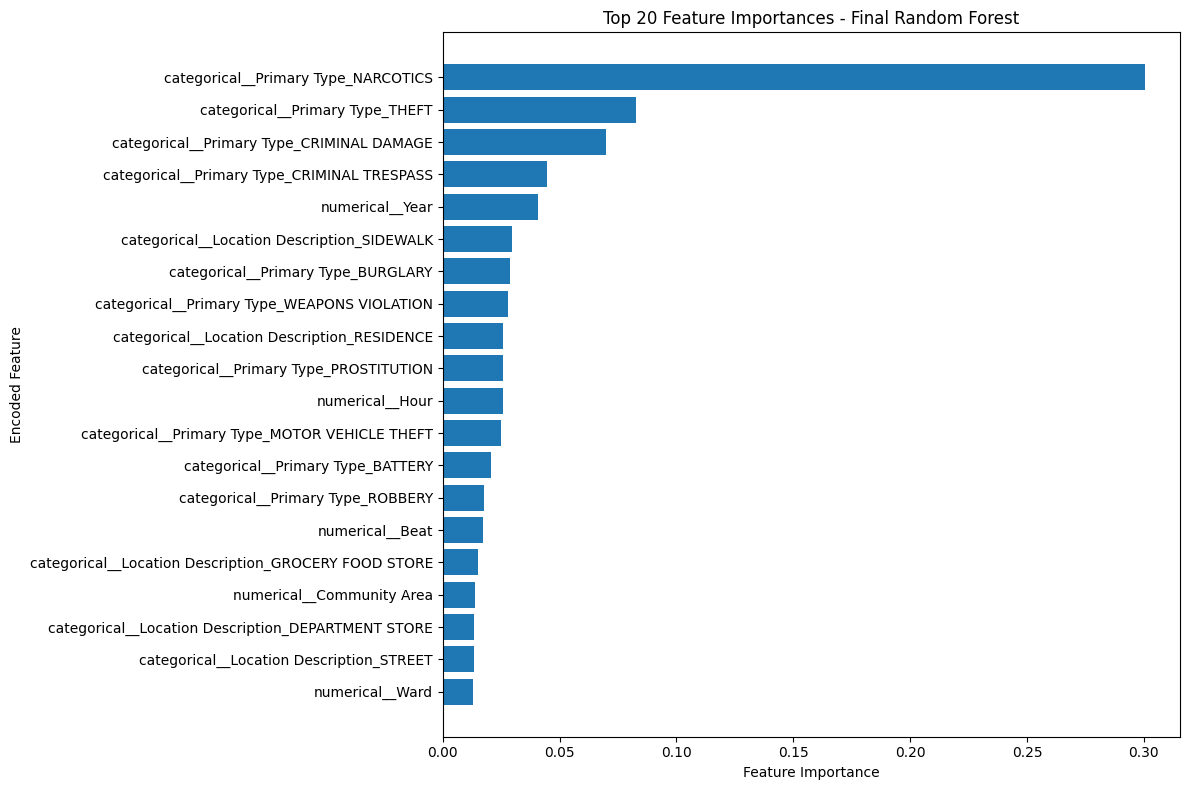


✅ Visualization created successfully!
Saved to: /content/drive/MyDrive/Army_Provost_ML_Project/Figures/Random_Forest_Top20_Feature_Importance.png


In [20]:
# ============================================================
# Top 20 Encoded Feature Importance
# ============================================================

import matplotlib.pyplot as plt
import os

print("=" * 70)
print("Creating Top 20 Feature Importance Visualization")
print("=" * 70)

top20_features = (
    feature_importance_df
    .head(20)
    .sort_values(
        by="Importance",
        ascending=True
    )
)

plt.figure(figsize=(12, 8))

plt.barh(
    top20_features["Feature"],
    top20_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Encoded Feature")
plt.title(
    "Top 20 Feature Importances - Final Random Forest"
)

plt.tight_layout()

# Save figure
top20_path = os.path.join(
    FIGURES_PATH,
    "Random_Forest_Top20_Feature_Importance.png"
)

plt.savefig(
    top20_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ Visualization created successfully!")
print(f"Saved to: {top20_path}")

# ============================================================
# Aggregated Random Forest Feature Importance
# ============================================================

This visualization presents Random Forest feature importance
aggregated at the level of the original project features.

For categorical variables, the importance values of their
one-hot encoded categories are summed to represent the overall
importance of the original feature.

Creating Aggregated Feature Importance Visualization


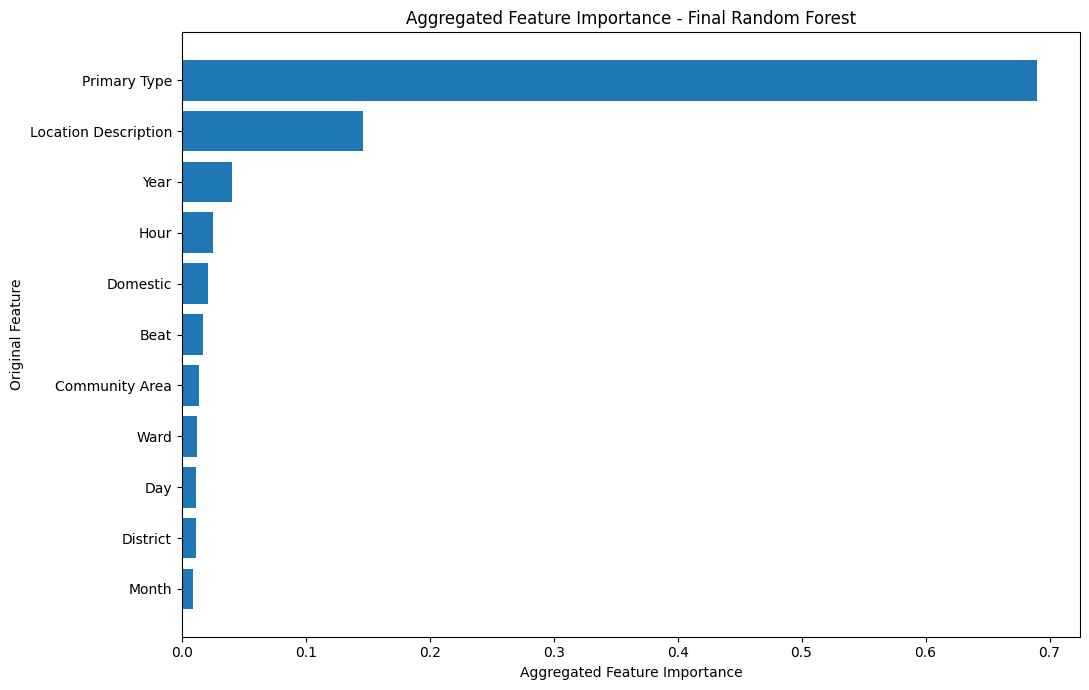


✅ Aggregated visualization created successfully!
Saved to: /content/drive/MyDrive/Army_Provost_ML_Project/Figures/Random_Forest_Aggregated_Feature_Importance.png


In [21]:
# ============================================================
# Aggregated Feature Importance Visualization
# ============================================================

import matplotlib.pyplot as plt
import os

print("=" * 70)
print("Creating Aggregated Feature Importance Visualization")
print("=" * 70)

# Sort for horizontal bar chart
aggregated_plot_df = (
    aggregated_importance_df
    .sort_values(
        by="Importance",
        ascending=True
    )
)

plt.figure(figsize=(11, 7))

plt.barh(
    aggregated_plot_df["Original Feature"],
    aggregated_plot_df["Importance"]
)

plt.xlabel("Aggregated Feature Importance")
plt.ylabel("Original Feature")
plt.title(
    "Aggregated Feature Importance - Final Random Forest"
)

plt.tight_layout()

# Save figure
aggregated_path = os.path.join(
    FIGURES_PATH,
    "Random_Forest_Aggregated_Feature_Importance.png"
)

plt.savefig(
    aggregated_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ Aggregated visualization created successfully!")
print(f"Saved to: {aggregated_path}")

# ============================================================
# Save Random Forest Feature Importance Results
# ============================================================

The encoded and aggregated feature importance results are
saved as CSV files for reporting, reproducibility, and
future analysis.

In [22]:
# ============================================================
# Save Feature Importance Results
# ============================================================

import os

print("=" * 70)
print("Saving Feature Importance Results")
print("=" * 70)

# ------------------------------------------------------------
# Save Top 20 Encoded Feature Importance
# ------------------------------------------------------------

top20_output_path = os.path.join(
    OUTPUTS_PATH,
    "Random_Forest_Top20_Feature_Importance.csv"
)

feature_importance_df.head(20).to_csv(
    top20_output_path,
    index=False
)

# ------------------------------------------------------------
# Save Aggregated Feature Importance
# ------------------------------------------------------------

aggregated_output_path = os.path.join(
    OUTPUTS_PATH,
    "Random_Forest_Aggregated_Feature_Importance.csv"
)

aggregated_importance_df.to_csv(
    aggregated_output_path,
    index=False
)

# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------

print("\n✅ Feature importance results saved successfully!")

print(
    f"\nTop 20 encoded features:\n{top20_output_path}"
)

print(
    f"\nAggregated feature importance:\n"
    f"{aggregated_output_path}"
)

Saving Feature Importance Results

✅ Feature importance results saved successfully!

Top 20 encoded features:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/Random_Forest_Top20_Feature_Importance.csv

Aggregated feature importance:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/Random_Forest_Aggregated_Feature_Importance.csv


# ============================================================
# Final Model Performance Comparison
# ============================================================

The performance of Logistic Regression, Random Forest, and
CatBoost is compared using the following evaluation metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Training Time
- Prediction Time

The comparison is used to assess the most suitable model for
the Army Provost crime prediction decision-support system.

In [23]:
# ============================================================
# Final Model Performance Comparison
# ============================================================

import pandas as pd
import os

print("=" * 70)
print("Final Model Performance Comparison")
print("=" * 70)

model_comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost"
    ],

    "Accuracy": [
        0.8301,
        0.8672,
        0.8838
    ],

    "Precision": [
        0.6539,
        0.7733,
        0.8955
    ],

    "Recall": [
        0.6824,
        0.6640,
        0.6065
    ],

    "F1 Score": [
        0.6678,
        0.7145,
        0.7232
    ],

    "ROC-AUC": [
        0.8748,
        0.8882,
        0.8981
    ],

    "Training Time (s)": [
        20.6913,
        704.25,
        539.74
    ],

    "Prediction Time (s)": [
        0.0463,
        7.17,
        15.25
    ]
})

print("\n")
print(
    model_comparison_df.to_string(index=False)
)

print("\n" + "=" * 70)
print("Best Model by Individual Metric")
print("=" * 70)

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]:
    best_model = model_comparison_df.loc[
        model_comparison_df[metric].idxmax(),
        "Model"
    ]

    best_value = model_comparison_df[metric].max()

    print(
        f"{metric:<15} : "
        f"{best_model:<20} ({best_value:.4f})"
    )

Final Model Performance Comparison


              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  Training Time (s)  Prediction Time (s)
Logistic Regression    0.8301     0.6539  0.6824    0.6678   0.8748            20.6913               0.0463
      Random Forest    0.8672     0.7733  0.6640    0.7145   0.8882           704.2500               7.1700
           CatBoost    0.8838     0.8955  0.6065    0.7232   0.8981           539.7400              15.2500

Best Model by Individual Metric
Accuracy        : CatBoost             (0.8838)
Precision       : CatBoost             (0.8955)
Recall          : Logistic Regression  (0.6824)
F1 Score        : CatBoost             (0.7232)
ROC-AUC         : CatBoost             (0.8981)


# ============================================================
# Model Performance Comparison
# ============================================================

The primary evaluation metrics of Logistic Regression,
Random Forest, and CatBoost are compared visually.

The visualization focuses on:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Creating Model Performance Comparison


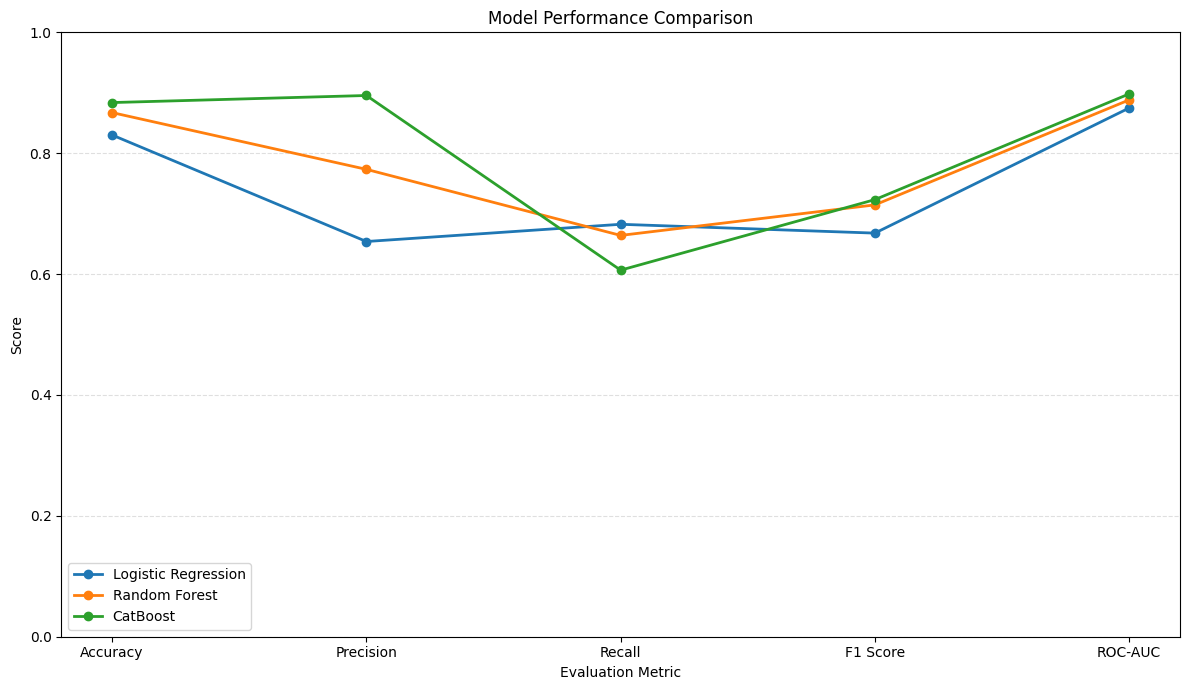


✅ Model comparison visualization created!
Saved to: /content/drive/MyDrive/Army_Provost_ML_Project/Figures/Model_Performance_Comparison.png


In [24]:
# ============================================================
# Model Performance Comparison Visualization
# ============================================================

import matplotlib.pyplot as plt
import os

print("=" * 70)
print("Creating Model Performance Comparison")
print("=" * 70)

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

models = model_comparison_df["Model"].tolist()

x = range(len(metrics))

plt.figure(figsize=(12, 7))

for i, model in enumerate(models):
    values = model_comparison_df.loc[
        model_comparison_df["Model"] == model,
        metrics
    ].values[0]

    plt.plot(
        x,
        values,
        marker="o",
        linewidth=2,
        label=model
    )

plt.xticks(
    x,
    metrics
)

plt.ylabel("Score")
plt.xlabel("Evaluation Metric")

plt.title(
    "Model Performance Comparison"
)

plt.ylim(0, 1.0)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

# ------------------------------------------------------------
# Save Figure
# ------------------------------------------------------------

comparison_path = os.path.join(
    FIGURES_PATH,
    "Model_Performance_Comparison.png"
)

plt.savefig(
    comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ Model comparison visualization created!")
print(f"Saved to: {comparison_path}")

# ============================================================
# Save Final Model Comparison Results
# ============================================================

The final performance comparison of all trained models is
saved as a CSV file for reporting, reproducibility, and
future analysis.

In [25]:
# ============================================================
# Save Model Comparison Results
# ============================================================

import os

print("=" * 70)
print("Saving Model Comparison Results")
print("=" * 70)

comparison_output_path = os.path.join(
    OUTPUTS_PATH,
    "Final_Model_Performance_Comparison.csv"
)

model_comparison_df.to_csv(
    comparison_output_path,
    index=False
)

print("\n✅ Model comparison results saved successfully!")
print(f"Saved to: {comparison_output_path}")

Saving Model Comparison Results

✅ Model comparison results saved successfully!
Saved to: /content/drive/MyDrive/Army_Provost_ML_Project/Outputs/Final_Model_Performance_Comparison.csv


In [32]:
# ============================================================
# Generate Random Forest Probability Scores for ROC Analysis
# ============================================================

import time
import numpy as np

print("=" * 70)
print("GENERATING RANDOM FOREST PROBABILITY SCORES")
print("=" * 70)

start_time = time.time()

# Probability of the positive class: Arrest = True
rf_y_proba = final_rf_model.predict_proba(X_test_processed)[:, 1]

prediction_time = time.time() - start_time

print(f"Prediction completed successfully.")
print(f"Prediction time: {prediction_time:.2f} seconds")
print(f"Number of probability scores: {len(rf_y_proba):,}")
print(f"Expected test samples: {len(y_test):,}")

print("\nProbability score range:")
print(f"Minimum: {rf_y_proba.min():.6f}")
print(f"Maximum: {rf_y_proba.max():.6f}")

print("\nFirst 10 probability scores:")
print(rf_y_proba[:10])

# Basic validation
if len(rf_y_proba) != len(y_test):
    raise ValueError(
        "Prediction count does not match y_test count."
    )

if not np.isfinite(rf_y_proba).all():
    raise ValueError(
        "Probability predictions contain NaN or infinite values."
    )

print("=" * 70)
print("RANDOM FOREST PROBABILITY VALIDATION PASSED")
print("=" * 70)

GENERATING RANDOM FOREST PROBABILITY SCORES
Prediction completed successfully.
Prediction time: 5.05 seconds
Number of probability scores: 344,110
Expected test samples: 344,110

Probability score range:
Minimum: 0.068964
Maximum: 0.986307

First 10 probability scores:
[0.29575527 0.93912484 0.48213635 0.92081922 0.79768602 0.35056654
 0.50159403 0.44354167 0.43404802 0.40319535]
RANDOM FOREST PROBABILITY VALIDATION PASSED


In [33]:
# ============================================================
# Random Forest ROC-AUC Analysis
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score
import pandas as pd
import os

print("=" * 70)
print("RANDOM FOREST ROC-AUC ANALYSIS")
print("=" * 70)

# Calculate ROC curve
rf_fpr, rf_tpr, rf_thresholds = roc_curve(
    y_test,
    rf_y_proba
)

# Calculate ROC-AUC
rf_roc_auc = roc_auc_score(
    y_test,
    rf_y_proba
)

print(f"ROC-AUC: {rf_roc_auc:.4f}")
print(f"Number of ROC points: {len(rf_fpr):,}")

print("\nInterpretation:")
print(
    f"The saved Random Forest achieves a ROC-AUC of "
    f"{rf_roc_auc:.4f} on the held-out test set."
)

# ------------------------------------------------------------
# Save ROC data
# ------------------------------------------------------------

PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"
OUTPUTS_PATH = os.path.join(PROJECT_ROOT, "Outputs")

rf_roc_data = pd.DataFrame({
    "False_Positive_Rate": rf_fpr,
    "True_Positive_Rate": rf_tpr,
    "Threshold": rf_thresholds
})

rf_roc_output_path = os.path.join(
    OUTPUTS_PATH,
    "Random_Forest_ROC_Data.csv"
)

rf_roc_data.to_csv(
    rf_roc_output_path,
    index=False
)

print(f"\nROC data saved successfully:")
print(rf_roc_output_path)

# ------------------------------------------------------------
# Display sample of ROC data
# ------------------------------------------------------------

print("\nFirst 10 ROC points:")
display(rf_roc_data.head(10))

print("=" * 70)
print("RANDOM FOREST ROC ANALYSIS COMPLETED")
print("=" * 70)

RANDOM FOREST ROC-AUC ANALYSIS
ROC-AUC: 0.8882
Number of ROC points: 70,660

Interpretation:
The saved Random Forest achieves a ROC-AUC of 0.8882 on the held-out test set.

ROC data saved successfully:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/Random_Forest_ROC_Data.csv

First 10 ROC points:


,False_Positive_Rate,True_Positive_Rate,Threshold
0,0.0,0.000000,inf
1,0.0,0.000012,0.986307
2,0.0,0.000395,0.984161
3,0.0,0.000418,0.984129
4,0.0,0.000673,0.983767
5,0.0,0.000697,0.983757
6,0.0,0.000813,0.983551
7,0.0,0.000836,0.983546
8,0.0,0.000859,0.983525
9,0.0,0.000882,0.983525


RANDOM FOREST ROC ANALYSIS COMPLETED


GENERATING RANDOM FOREST ROC CURVE


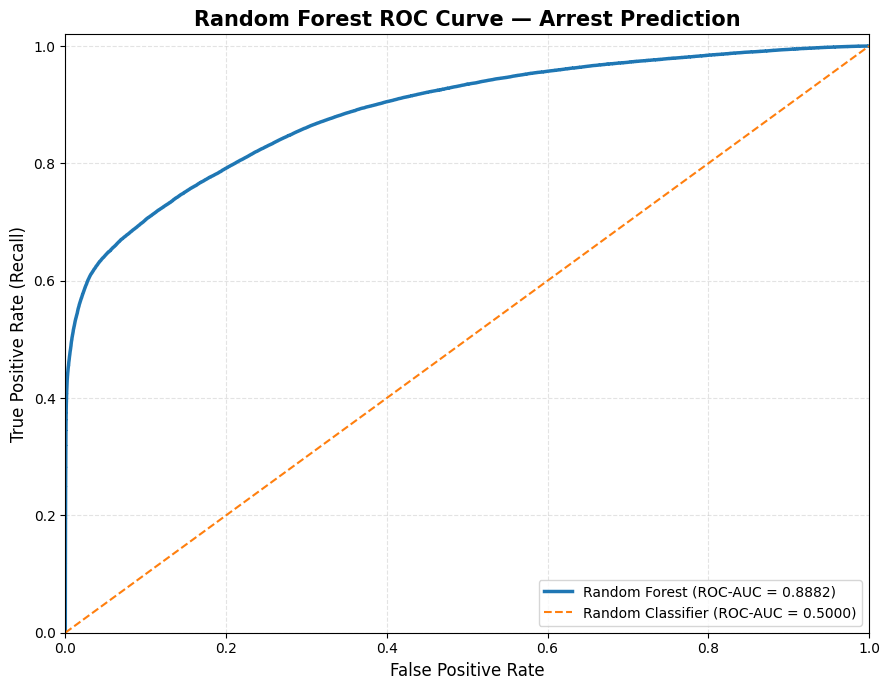

RANDOM FOREST ROC CURVE SAVED
ROC-AUC: 0.8882
Figure saved to:
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/Random_Forest_ROC_Curve.png


In [34]:
# ============================================================
# Random Forest ROC Curve
# ============================================================

import matplotlib.pyplot as plt
import os

print("=" * 70)
print("GENERATING RANDOM FOREST ROC CURVE")
print("=" * 70)

# Exact existing project paths
PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"
FIGURES_PATH = os.path.join(PROJECT_ROOT, "Figures")

# Create ROC figure
plt.figure(figsize=(9, 7))

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2.5,
    label=f"Random Forest (ROC-AUC = {rf_roc_auc:.4f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier (ROC-AUC = 0.5000)"
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)

plt.title(
    "Random Forest ROC Curve — Arrest Prediction",
    fontsize=15,
    fontweight="bold"
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.grid(
    True,
    linestyle="--",
    alpha=0.35
)

plt.legend(
    loc="lower right",
    fontsize=10
)

plt.tight_layout()

# Save publication-quality figure
rf_roc_figure_path = os.path.join(
    FIGURES_PATH,
    "Random_Forest_ROC_Curve.png"
)

plt.savefig(
    rf_roc_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("RANDOM FOREST ROC CURVE SAVED")
print("=" * 70)
print(f"ROC-AUC: {rf_roc_auc:.4f}")
print(f"Figure saved to:")
print(rf_roc_figure_path)

In [35]:
# ============================================================
# Check Available Prediction / Evaluation Variables
# ============================================================

print("=" * 70)
print("CHECKING AVAILABLE PREDICTION VARIABLES")
print("=" * 70)

prediction_variables = []

for name, obj in globals().items():
    name_lower = name.lower()

    if any(keyword in name_lower for keyword in [
        "proba",
        "probability",
        "prediction",
        "pred",
        "roc_auc",
        "auc",
        "fpr",
        "tpr"
    ]):
        prediction_variables.append(
            (name, type(obj).__name__, getattr(obj, "shape", "N/A"))
        )

if prediction_variables:
    for name, obj_type, shape in prediction_variables:
        print(f"{name:<40} : {obj_type:<20} Shape: {shape}")
else:
    print("No prediction/evaluation variables currently available.")

print("=" * 70)

CHECKING AVAILABLE PREDICTION VARIABLES
roc_auc_score                            : function             Shape: N/A
rf_predictions                           : ndarray              Shape: (344110,)
rf_probabilities                         : ndarray              Shape: (344110,)
prediction_time                          : float                Shape: N/A
rf_roc_auc                               : float64              Shape: ()
rf_y_proba                               : ndarray              Shape: (344110,)
rf_fpr                                   : ndarray              Shape: (70660,)
rf_tpr                                   : ndarray              Shape: (70660,)
prediction_variables                     : list                 Shape: N/A


In [36]:
# ============================================================
# Recover Original Logistic Regression and CatBoost Configuration
# ============================================================

import os
import json

NOTEBOOK_PATH = (
    "/content/drive/MyDrive/Army_Provost_ML_Project/"
    "Notebooks/05_Machine_Learning_Modeling.ipynb"
)

print("=" * 70)
print("CHECKING MODEL TRAINING CELLS IN CURRENT NOTEBOOK")
print("=" * 70)

if not os.path.exists(NOTEBOOK_PATH):
    raise FileNotFoundError(
        f"Notebook not found at:\n{NOTEBOOK_PATH}"
    )

with open(NOTEBOOK_PATH, "r", encoding="utf-8") as f:
    notebook = json.load(f)

matches = []

keywords = [
    "LogisticRegression",
    "CatBoostClassifier",
    "CatBoost",
    "logistic",
    "catboost"
]

for cell_number, cell in enumerate(
    notebook.get("cells", [])
):

    if cell.get("cell_type") != "code":
        continue

    source = "".join(cell.get("source", []))

    if any(keyword.lower() in source.lower() for keyword in keywords):
        matches.append(
            (cell_number, source)
        )

print(f"Found {len(matches)} relevant code cells.\n")

for cell_number, source in matches:
    print("=" * 70)
    print(f"CELL {cell_number}")
    print("=" * 70)
    print(source)
    print()

print("=" * 70)
print("NOTEBOOK INSPECTION COMPLETED")
print("=" * 70)

CHECKING MODEL TRAINING CELLS IN CURRENT NOTEBOOK
Found 9 relevant code cells.

CELL 2
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

# Models

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,

In [37]:
# ============================================================
# Recover Logistic Regression for ROC Analysis
# ============================================================

import time
import os
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

print("=" * 70)
print("RECOVERING LOGISTIC REGRESSION FOR ROC ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Exact established feature definitions
# ------------------------------------------------------------

categorical_features = [
    "Primary Type",
    "Location Description",
    "Domestic"
]

numerical_features = [
    "Year",
    "Month",
    "Day",
    "Hour",
    "District",
    "Beat",
    "Ward",
    "Community Area"
]

# ------------------------------------------------------------
# Recreate the ORIGINAL Logistic Regression preprocessor
# ------------------------------------------------------------

lr_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        ),
        (
            "numerical",
            Pipeline([
                ("scaler", StandardScaler())
            ]),
            numerical_features
        )
    ]
)

print("Fitting original Logistic Regression preprocessing...")

X_train_lr = lr_preprocessor.fit_transform(X_train)
X_test_lr = lr_preprocessor.transform(X_test)

print(f"Training shape: {X_train_lr.shape}")
print(f"Testing shape : {X_test_lr.shape}")

# ------------------------------------------------------------
# Train EXACT original Logistic Regression configuration
# ------------------------------------------------------------

print("\nTraining Logistic Regression...")

start_time = time.time()

lr_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=500,
    solver="lbfgs"
)

lr_model.fit(X_train_lr, y_train)

lr_training_time = time.time() - start_time

print(f"Training completed in {lr_training_time:.2f} seconds")

# ------------------------------------------------------------
# Generate predictions and probability scores
# ------------------------------------------------------------

print("\nGenerating Logistic Regression probabilities...")

start_time = time.time()

lr_predictions = lr_model.predict(X_test_lr)
lr_y_proba = lr_model.predict_proba(X_test_lr)[:, 1]

lr_prediction_time = time.time() - start_time

print(f"Prediction completed in {lr_prediction_time:.2f} seconds")
print(f"Probability scores: {len(lr_y_proba):,}")

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

if len(lr_y_proba) != len(y_test):
    raise ValueError(
        "Logistic Regression probability count does not "
        "match y_test."
    )

# ------------------------------------------------------------
# Calculate ROC-AUC
# ------------------------------------------------------------

from sklearn.metrics import roc_auc_score

lr_roc_auc = roc_auc_score(
    y_test,
    lr_y_proba
)

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION ROC RECOVERY RESULT")
print("=" * 70)

print(f"ROC-AUC: {lr_roc_auc:.4f}")
print(f"Expected previous ROC-AUC: 0.8748")
print(f"Training time: {lr_training_time:.2f} seconds")
print(f"Prediction time: {lr_prediction_time:.2f} seconds")

# ------------------------------------------------------------
# Save model artifacts to existing Models folder
# ------------------------------------------------------------

PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"
MODELS_PATH = os.path.join(PROJECT_ROOT, "Models")

lr_model_path = os.path.join(
    MODELS_PATH,
    "logistic_regression_model.pkl"
)

lr_preprocessor_path = os.path.join(
    MODELS_PATH,
    "logistic_regression_preprocessor.pkl"
)

joblib.dump(lr_model, lr_model_path)
joblib.dump(lr_preprocessor, lr_preprocessor_path)

print("\nLogistic Regression model saved:")
print(lr_model_path)

print("\nLogistic Regression preprocessor saved:")
print(lr_preprocessor_path)

print("=" * 70)
print("LOGISTIC REGRESSION RECOVERY COMPLETED")
print("=" * 70)

RECOVERING LOGISTIC REGRESSION FOR ROC ANALYSIS
Fitting original Logistic Regression preprocessing...
Training shape: (1376436, 231)
Testing shape : (344110, 231)

Training Logistic Regression...
Training completed in 25.87 seconds

Generating Logistic Regression probabilities...
Prediction completed in 0.03 seconds
Probability scores: 344,110

LOGISTIC REGRESSION ROC RECOVERY RESULT
ROC-AUC: 0.8748
Expected previous ROC-AUC: 0.8748
Training time: 25.87 seconds
Prediction time: 0.03 seconds

Logistic Regression model saved:
/content/drive/MyDrive/Army_Provost_ML_Project/Models/logistic_regression_model.pkl

Logistic Regression preprocessor saved:
/content/drive/MyDrive/Army_Provost_ML_Project/Models/logistic_regression_preprocessor.pkl
LOGISTIC REGRESSION RECOVERY COMPLETED


In [38]:
# ============================================================
# Logistic Regression ROC-AUC Analysis
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score
import pandas as pd
import os

print("=" * 70)
print("LOGISTIC REGRESSION ROC-AUC ANALYSIS")
print("=" * 70)

# Calculate ROC curve
lr_fpr, lr_tpr, lr_thresholds = roc_curve(
    y_test,
    lr_y_proba
)

# Calculate ROC-AUC
lr_roc_auc = roc_auc_score(
    y_test,
    lr_y_proba
)

print(f"ROC-AUC: {lr_roc_auc:.4f}")
print(f"Number of ROC points: {len(lr_fpr):,}")

# ------------------------------------------------------------
# Save ROC data
# ------------------------------------------------------------

PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"
OUTPUTS_PATH = os.path.join(PROJECT_ROOT, "Outputs")

lr_roc_data = pd.DataFrame({
    "False_Positive_Rate": lr_fpr,
    "True_Positive_Rate": lr_tpr,
    "Threshold": lr_thresholds
})

lr_roc_output_path = os.path.join(
    OUTPUTS_PATH,
    "Logistic_Regression_ROC_Data.csv"
)

lr_roc_data.to_csv(
    lr_roc_output_path,
    index=False
)

print("\nROC data saved successfully:")
print(lr_roc_output_path)

print("\nFirst 10 ROC points:")
display(lr_roc_data.head(10))

print("=" * 70)
print("LOGISTIC REGRESSION ROC ANALYSIS COMPLETED")
print("=" * 70)

LOGISTIC REGRESSION ROC-AUC ANALYSIS
ROC-AUC: 0.8748
Number of ROC points: 69,562

ROC data saved successfully:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/Logistic_Regression_ROC_Data.csv

First 10 ROC points:


,False_Positive_Rate,True_Positive_Rate,Threshold
0,0.000000,0.000000,inf
1,0.000000,0.000012,0.999903
2,0.000000,0.000453,0.999805
3,0.000004,0.000453,0.999805
4,0.000004,0.003529,0.999471
5,0.000008,0.003529,0.999470
6,0.000008,0.004261,0.999418
7,0.000012,0.004261,0.999417
8,0.000012,0.004516,0.999391
9,0.000016,0.004516,0.999387


LOGISTIC REGRESSION ROC ANALYSIS COMPLETED


In [39]:
# ============================================================
# Verify CatBoost Recovery Requirements
# ============================================================

print("=" * 70)
print("VERIFYING CATBOOST RECOVERY REQUIREMENTS")
print("=" * 70)

# Check CatBoost installation
try:
    import catboost
    from catboost import CatBoostClassifier

    print(f"CatBoost available: YES")
    print(f"CatBoost version: {catboost.__version__}")

except ImportError:
    print("CatBoost available: NO")

# Check required feature definitions
required_variables = [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "categorical_features"
]

print("\nRequired variables:")

all_available = True

for variable in required_variables:
    available = variable in globals()

    print(
        f"{variable:<25} : "
        f"{'AVAILABLE' if available else 'MISSING'}"
    )

    if not available:
        all_available = False

print("\n" + "=" * 70)

if all_available:
    print("CATBOOST RECOVERY REQUIREMENTS: READY")
else:
    print("CATBOOST RECOVERY REQUIREMENTS: NOT READY")

print("=" * 70)

VERIFYING CATBOOST RECOVERY REQUIREMENTS
CatBoost available: NO

Required variables:
X_train                   : AVAILABLE
X_test                    : AVAILABLE
y_train                   : AVAILABLE
y_test                    : AVAILABLE
categorical_features      : AVAILABLE

CATBOOST RECOVERY REQUIREMENTS: READY


In [40]:
# ============================================================
# Restore CatBoost Dependency
# ============================================================

print("=" * 70)
print("RESTORING CATBOOST DEPENDENCY")
print("=" * 70)

!pip install -q catboost

import catboost
from catboost import CatBoostClassifier

print(f"CatBoost installed successfully.")
print(f"CatBoost version: {catboost.__version__}")

print("=" * 70)
print("CATBOOST DEPENDENCY RESTORED")
print("=" * 70)

RESTORING CATBOOST DEPENDENCY
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.9 MB/s eta 0:00:00
CatBoost installed successfully.
CatBoost version: 1.2.10
CATBOOST DEPENDENCY RESTORED


In [41]:
# ============================================================
# Recover CatBoost for ROC Analysis
# ============================================================

import time
import os
import joblib

from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

print("=" * 70)
print("RECOVERING CATBOOST FOR ROC ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Identify categorical feature indices
# ------------------------------------------------------------

cat_features = [
    X_train.columns.get_loc(col)
    for col in categorical_features
]

print("Categorical feature indices:")
print(cat_features)

# ------------------------------------------------------------
# Create EXACT original CatBoost configuration
# ------------------------------------------------------------

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=8,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=50
)

print("\nOriginal CatBoost configuration:")
print("Iterations       : 300")
print("Learning Rate    : 0.1")
print("Depth            : 8")
print("Loss Function    : Logloss")
print("Evaluation Metric: AUC")
print("Random Seed      : 42")

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

print("\nStarting controlled CatBoost recovery...")
print("This is the original model configuration.")
print("No hyperparameter tuning is being performed.")

start_time = time.time()

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

cat_training_time = time.time() - start_time

print("\n" + "=" * 70)
print("CATBOOST TRAINING COMPLETED")
print("=" * 70)

print(f"Training time: {cat_training_time:.2f} seconds")

# ------------------------------------------------------------
# Generate predictions and probability scores
# ------------------------------------------------------------

print("\nGenerating CatBoost probability scores...")

start_time = time.time()

cat_predictions = cat_model.predict(X_test)
cat_y_proba = cat_model.predict_proba(X_test)[:, 1]

cat_prediction_time = time.time() - start_time

# ------------------------------------------------------------
# Calculate ROC-AUC
# ------------------------------------------------------------

cat_roc_auc = roc_auc_score(
    y_test,
    cat_y_proba
)

print(f"Prediction time: {cat_prediction_time:.2f} seconds")
print(f"Probability scores: {len(cat_y_proba):,}")
print(f"ROC-AUC: {cat_roc_auc:.4f}")

print("\nExpected previous results:")
print("ROC-AUC: 0.8981")
print("Training time: approximately 539.74 seconds")
print("Prediction time: approximately 15.25 seconds")

# ------------------------------------------------------------
# Validate probability output
# ------------------------------------------------------------

if len(cat_y_proba) != len(y_test):
    raise ValueError(
        "CatBoost probability count does not match y_test."
    )

# ------------------------------------------------------------
# Save CatBoost model
# ------------------------------------------------------------

PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"
MODELS_PATH = os.path.join(PROJECT_ROOT, "Models")

cat_model_path = os.path.join(
    MODELS_PATH,
    "catboost_model.pkl"
)

joblib.dump(
    cat_model,
    cat_model_path
)

print("\nCatBoost model saved:")
print(cat_model_path)

print("=" * 70)
print("CATBOOST RECOVERY COMPLETED")
print("=" * 70)

RECOVERING CATBOOST FOR ROC ANALYSIS
Categorical feature indices:
[0, 1, 2]

Original CatBoost configuration:
Iterations       : 300
Learning Rate    : 0.1
Depth            : 8
Loss Function    : Logloss
Evaluation Metric: AUC
Random Seed      : 42

Starting controlled CatBoost recovery...
This is the original model configuration.
No hyperparameter tuning is being performed.
0:	total: 3.4s	remaining: 16m 55s
50:	total: 1m 15s	remaining: 6m 10s
100:	total: 2m 32s	remaining: 5m
150:	total: 3m 47s	remaining: 3m 44s
200:	total: 5m 5s	remaining: 2m 30s
250:	total: 6m 23s	remaining: 1m 14s
299:	total: 7m 39s	remaining: 0us

CATBOOST TRAINING COMPLETED
Training time: 487.19 seconds

Generating CatBoost probability scores...
Prediction time: 5.73 seconds
Probability scores: 344,110
ROC-AUC: 0.8981

Expected previous results:
ROC-AUC: 0.8981
Training time: approximately 539.74 seconds
Prediction time: approximately 15.25 seconds

CatBoost model saved:
/content/drive/MyDrive/Army_Provost_ML_Proj

In [42]:
# ============================================================
# CatBoost ROC-AUC Analysis
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score
import pandas as pd
import os

print("=" * 70)
print("CATBOOST ROC-AUC ANALYSIS")
print("=" * 70)

# Calculate ROC curve
cat_fpr, cat_tpr, cat_thresholds = roc_curve(
    y_test,
    cat_y_proba
)

# Calculate ROC-AUC
cat_roc_auc = roc_auc_score(
    y_test,
    cat_y_proba
)

print(f"ROC-AUC: {cat_roc_auc:.4f}")
print(f"Number of ROC points: {len(cat_fpr):,}")

# ------------------------------------------------------------
# Save ROC data
# ------------------------------------------------------------

PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"
OUTPUTS_PATH = os.path.join(PROJECT_ROOT, "Outputs")

cat_roc_data = pd.DataFrame({
    "False_Positive_Rate": cat_fpr,
    "True_Positive_Rate": cat_tpr,
    "Threshold": cat_thresholds
})

cat_roc_output_path = os.path.join(
    OUTPUTS_PATH,
    "CatBoost_ROC_Data.csv"
)

cat_roc_data.to_csv(
    cat_roc_output_path,
    index=False
)

print("\nROC data saved successfully:")
print(cat_roc_output_path)

print("\nFirst 10 ROC points:")
display(cat_roc_data.head(10))

print("=" * 70)
print("CATBOOST ROC ANALYSIS COMPLETED")
print("=" * 70)

CATBOOST ROC-AUC ANALYSIS
ROC-AUC: 0.8981
Number of ROC points: 63,424

ROC data saved successfully:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/CatBoost_ROC_Data.csv

First 10 ROC points:


,False_Positive_Rate,True_Positive_Rate,Threshold
0,0.0,0.000000,inf
1,0.0,0.000012,0.999708
2,0.0,0.000522,0.999527
3,0.0,0.000546,0.999526
4,0.0,0.001846,0.999445
5,0.0,0.001869,0.999445
6,0.0,0.002241,0.999427
7,0.0,0.002264,0.999426
8,0.0,0.003320,0.999392
9,0.0,0.003343,0.999392


CATBOOST ROC ANALYSIS COMPLETED


GENERATING COMBINED ROC CURVE COMPARISON


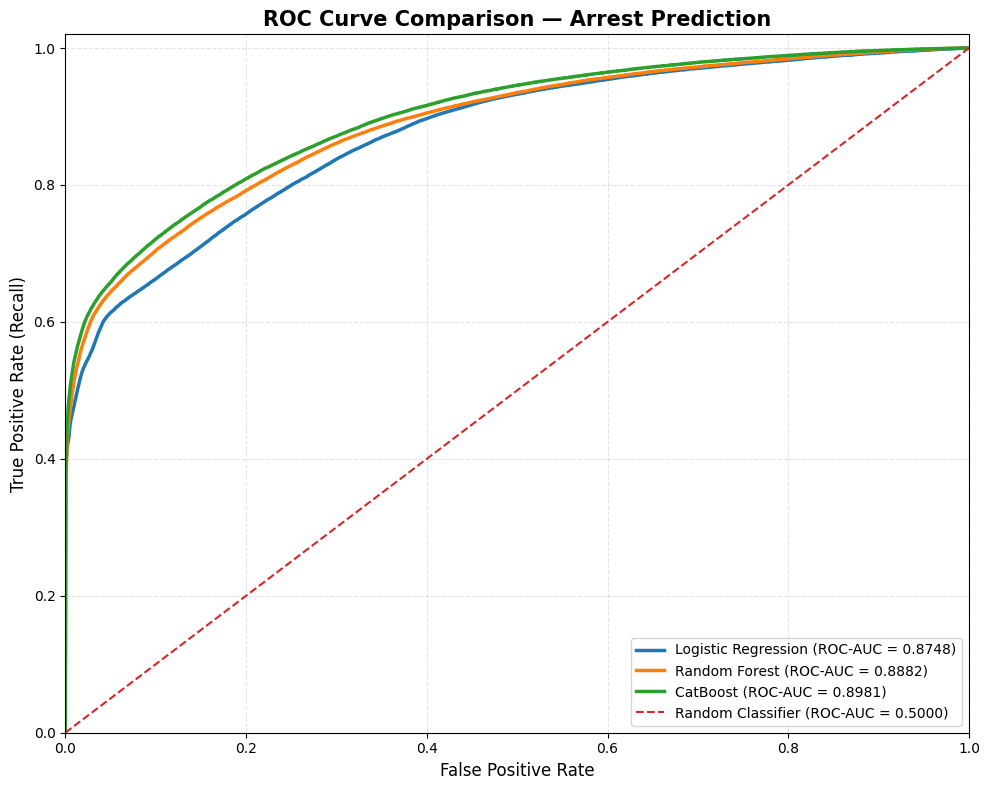

COMBINED ROC CURVE SAVED
Logistic Regression ROC-AUC : 0.8748
Random Forest ROC-AUC       : 0.8882
CatBoost ROC-AUC            : 0.8981

Figure saved to:
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/ROC_Curve_Model_Comparison.png


In [43]:
# ============================================================
# Combined ROC Curve — Model Comparison
# ============================================================

import matplotlib.pyplot as plt
import os

print("=" * 70)
print("GENERATING COMBINED ROC CURVE COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# Exact existing project path
# ------------------------------------------------------------

PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"
FIGURES_PATH = os.path.join(PROJECT_ROOT, "Figures")

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

# Logistic Regression
plt.plot(
    lr_fpr,
    lr_tpr,
    linewidth=2.5,
    label=f"Logistic Regression (ROC-AUC = {lr_roc_auc:.4f})"
)

# Random Forest
plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2.5,
    label=f"Random Forest (ROC-AUC = {rf_roc_auc:.4f})"
)

# CatBoost
plt.plot(
    cat_fpr,
    cat_tpr,
    linewidth=2.5,
    label=f"CatBoost (ROC-AUC = {cat_roc_auc:.4f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier (ROC-AUC = 0.5000)"
)

# ------------------------------------------------------------
# Labels and formatting
# ------------------------------------------------------------

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate (Recall)",
    fontsize=12
)

plt.title(
    "ROC Curve Comparison — Arrest Prediction",
    fontsize=15,
    fontweight="bold"
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.grid(
    True,
    linestyle="--",
    alpha=0.35
)

plt.legend(
    loc="lower right",
    fontsize=10
)

plt.tight_layout()

# ------------------------------------------------------------
# Save publication-quality figure
# ------------------------------------------------------------

roc_comparison_path = os.path.join(
    FIGURES_PATH,
    "ROC_Curve_Model_Comparison.png"
)

plt.savefig(
    roc_comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("COMBINED ROC CURVE SAVED")
print("=" * 70)

print(f"Logistic Regression ROC-AUC : {lr_roc_auc:.4f}")
print(f"Random Forest ROC-AUC       : {rf_roc_auc:.4f}")
print(f"CatBoost ROC-AUC            : {cat_roc_auc:.4f}")

print("\nFigure saved to:")
print(roc_comparison_path)

PRECISION-RECALL CURVE COMPARISON

Average Precision (AP):
Logistic Regression : 0.7927
Random Forest       : 0.8159
CatBoost            : 0.8300

Positive-class prevalence:
Arrest = True : 0.2503 (25.03%)


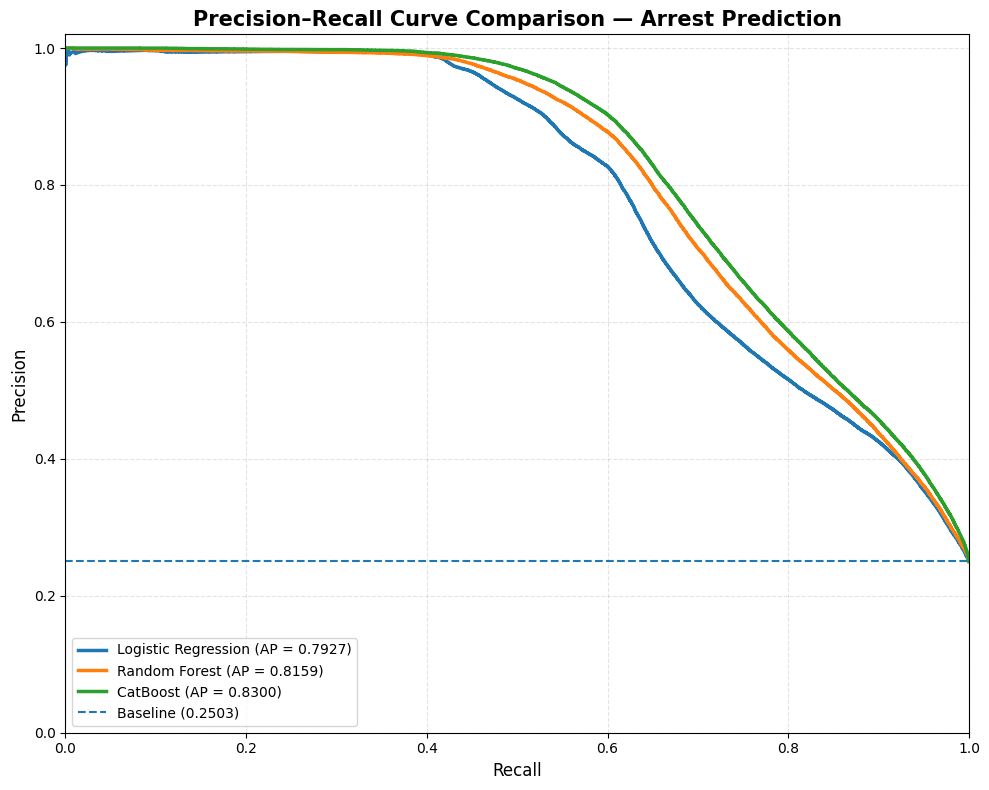


PRECISION-RECALL SUMMARY
              Model  Average Precision
Logistic Regression             0.7927
      Random Forest             0.8159
           CatBoost             0.8300

PR data saved:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/Logistic_Regression_PR_Data.csv
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/Random_Forest_PR_Data.csv
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/CatBoost_PR_Data.csv

Figure saved:
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/Precision_Recall_Curve_Model_Comparison.png
PRECISION-RECALL ANALYSIS COMPLETED


In [44]:
# ============================================================
# Precision-Recall Curve Comparison
# ============================================================

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)
import pandas as pd
import matplotlib.pyplot as plt
import os

print("=" * 70)
print("PRECISION-RECALL CURVE COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"
FIGURES_PATH = os.path.join(PROJECT_ROOT, "Figures")
OUTPUTS_PATH = os.path.join(PROJECT_ROOT, "Outputs")

# ------------------------------------------------------------
# Calculate Precision-Recall curves
# ------------------------------------------------------------

lr_precision_curve, lr_recall_curve, lr_pr_thresholds = (
    precision_recall_curve(y_test, lr_y_proba)
)

rf_precision_curve, rf_recall_curve, rf_pr_thresholds = (
    precision_recall_curve(y_test, rf_y_proba)
)

cat_precision_curve, cat_recall_curve, cat_pr_thresholds = (
    precision_recall_curve(y_test, cat_y_proba)
)

# ------------------------------------------------------------
# Average Precision
# ------------------------------------------------------------

lr_ap = average_precision_score(
    y_test,
    lr_y_proba
)

rf_ap = average_precision_score(
    y_test,
    rf_y_proba
)

cat_ap = average_precision_score(
    y_test,
    cat_y_proba
)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\nAverage Precision (AP):")

print(f"Logistic Regression : {lr_ap:.4f}")
print(f"Random Forest       : {rf_ap:.4f}")
print(f"CatBoost            : {cat_ap:.4f}")

print("\nPositive-class prevalence:")
positive_rate = y_test.mean()
print(f"Arrest = True : {positive_rate:.4f} ({positive_rate * 100:.2f}%)")

# ------------------------------------------------------------
# Save PR data
# ------------------------------------------------------------

lr_pr_data = pd.DataFrame({
    "Precision": lr_precision_curve,
    "Recall": lr_recall_curve
})

rf_pr_data = pd.DataFrame({
    "Precision": rf_precision_curve,
    "Recall": rf_recall_curve
})

cat_pr_data = pd.DataFrame({
    "Precision": cat_precision_curve,
    "Recall": cat_recall_curve
})

lr_pr_path = os.path.join(
    OUTPUTS_PATH,
    "Logistic_Regression_PR_Data.csv"
)

rf_pr_path = os.path.join(
    OUTPUTS_PATH,
    "Random_Forest_PR_Data.csv"
)

cat_pr_path = os.path.join(
    OUTPUTS_PATH,
    "CatBoost_PR_Data.csv"
)

lr_pr_data.to_csv(lr_pr_path, index=False)
rf_pr_data.to_csv(rf_pr_path, index=False)
cat_pr_data.to_csv(cat_pr_path, index=False)

# ------------------------------------------------------------
# Create comparison figure
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

plt.plot(
    lr_recall_curve,
    lr_precision_curve,
    linewidth=2.5,
    label=f"Logistic Regression (AP = {lr_ap:.4f})"
)

plt.plot(
    rf_recall_curve,
    rf_precision_curve,
    linewidth=2.5,
    label=f"Random Forest (AP = {rf_ap:.4f})"
)

plt.plot(
    cat_recall_curve,
    cat_precision_curve,
    linewidth=2.5,
    label=f"CatBoost (AP = {cat_ap:.4f})"
)

# Baseline = positive-class prevalence
plt.axhline(
    y=positive_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline ({positive_rate:.4f})"
)

plt.xlabel(
    "Recall",
    fontsize=12
)

plt.ylabel(
    "Precision",
    fontsize=12
)

plt.title(
    "Precision–Recall Curve Comparison — Arrest Prediction",
    fontsize=15,
    fontweight="bold"
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.grid(
    True,
    linestyle="--",
    alpha=0.35
)

plt.legend(
    loc="lower left",
    fontsize=10
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

pr_comparison_path = os.path.join(
    FIGURES_PATH,
    "Precision_Recall_Curve_Model_Comparison.png"
)

plt.savefig(
    pr_comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

pr_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost"
    ],
    "Average Precision": [
        lr_ap,
        rf_ap,
        cat_ap
    ]
})

pr_summary["Average Precision"] = (
    pr_summary["Average Precision"].round(4)
)

print("\n" + "=" * 70)
print("PRECISION-RECALL SUMMARY")
print("=" * 70)

print(pr_summary.to_string(index=False))

print("\nPR data saved:")
print(lr_pr_path)
print(rf_pr_path)
print(cat_pr_path)

print("\nFigure saved:")
print(pr_comparison_path)

print("=" * 70)
print("PRECISION-RECALL ANALYSIS COMPLETED")
print("=" * 70)

In [45]:
# ============================================================
# Random Forest Decision Threshold Analysis
# ============================================================

import numpy as np
import pandas as pd
import os

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=" * 70)
print("RANDOM FOREST DECISION THRESHOLD ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Use already validated Random Forest probabilities
# ------------------------------------------------------------

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70
]

threshold_results = []

for threshold in thresholds:

    # Convert probability to class prediction
    threshold_predictions = (
        rf_y_proba >= threshold
    ).astype(int)

    # Metrics
    accuracy = accuracy_score(
        y_test,
        threshold_predictions
    )

    precision = precision_score(
        y_test,
        threshold_predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        threshold_predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        threshold_predictions,
        zero_division=0
    )

    # Confusion matrix
    cm = confusion_matrix(
        y_test,
        threshold_predictions
    )

    tn, fp, fn, tp = cm.ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp
    })

# ------------------------------------------------------------
# Create results DataFrame
# ------------------------------------------------------------

threshold_df = pd.DataFrame(
    threshold_results
)

# Round metrics for display
display_threshold_df = threshold_df.copy()

display_threshold_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
] = display_threshold_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
].round(4)

print("\nThreshold Performance:")
print(
    display_threshold_df.to_string(index=False)
)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"
OUTPUTS_PATH = os.path.join(
    PROJECT_ROOT,
    "Outputs"
)

threshold_output_path = os.path.join(
    OUTPUTS_PATH,
    "Random_Forest_Decision_Threshold_Analysis.csv"
)

threshold_df.to_csv(
    threshold_output_path,
    index=False
)

print("\nThreshold analysis saved to:")
print(threshold_output_path)

# ------------------------------------------------------------
# Highlight standard 0.50 threshold
# ------------------------------------------------------------

standard_row = threshold_df[
    threshold_df["Threshold"] == 0.50
].iloc[0]

print("\n" + "=" * 70)
print("STANDARD 0.50 THRESHOLD")
print("=" * 70)

print(
    f"Accuracy        : {standard_row['Accuracy']:.4f}"
)

print(
    f"Precision       : {standard_row['Precision']:.4f}"
)

print(
    f"Arrest Recall   : {standard_row['Recall']:.4f}"
)

print(
    f"F1 Score        : {standard_row['F1 Score']:.4f}"
)

print(
    f"False Positives : {int(standard_row['False Positives']):,}"
)

print(
    f"False Negatives : {int(standard_row['False Negatives']):,}"
)

print("=" * 70)
print("THRESHOLD ANALYSIS COMPLETED")
print("=" * 70)

RANDOM FOREST DECISION THRESHOLD ANALYSIS

Threshold Performance:
 Threshold  Accuracy  Precision  Recall  F1 Score  True Negatives  False Positives  False Negatives  True Positives
      0.30    0.6225     0.3927  0.9293    0.5521          134176           123795             6092           80047
      0.35    0.6968     0.4472  0.8940    0.5962          162786            95185             9134           77005
      0.40    0.7510     0.5015  0.8499    0.6308          185202            72769            12927           73212
      0.45    0.8180     0.6088  0.7635    0.6774          215704            42267            20368           65771
      0.50    0.8672     0.7733  0.6640    0.7145          241206            16765            28942           57197
      0.55    0.8789     0.8690  0.6077    0.7152          250077             7894            33794           52345
      0.60    0.8773     0.9076  0.5674    0.6983          252998             4973            37266           48873
      

GENERATING RANDOM FOREST THRESHOLD TRADE-OFF FIGURE


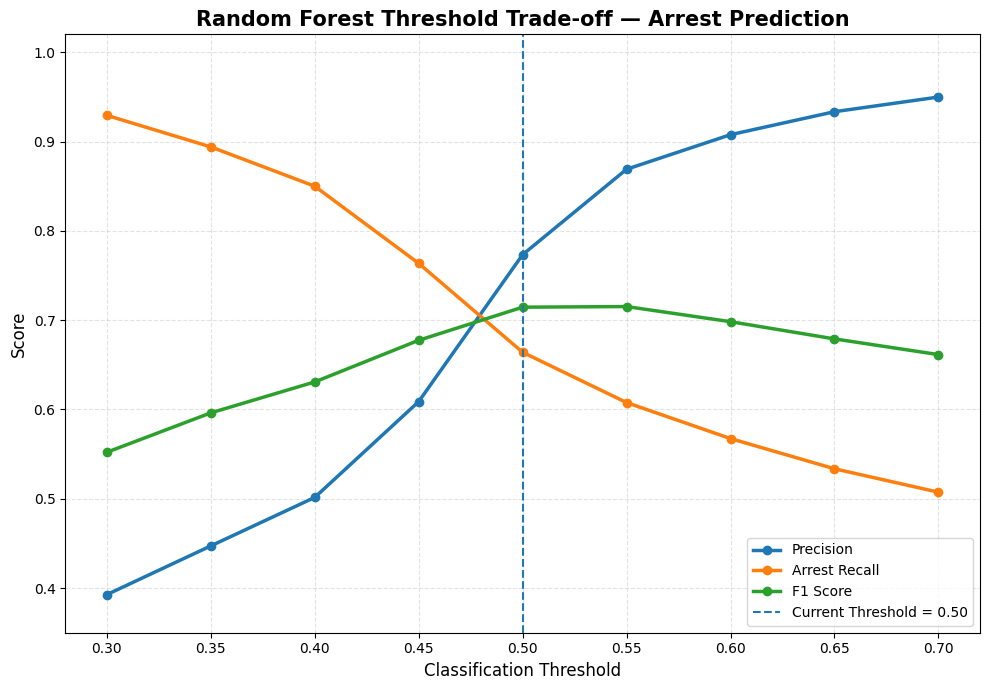

THRESHOLD TRADE-OFF FIGURE SAVED
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/Random_Forest_Threshold_Tradeoff.png


In [46]:
# ============================================================
# Random Forest Threshold Trade-off Visualization
# ============================================================

import matplotlib.pyplot as plt
import os

print("=" * 70)
print("GENERATING RANDOM FOREST THRESHOLD TRADE-OFF FIGURE")
print("=" * 70)

# ------------------------------------------------------------
# Project path
# ------------------------------------------------------------

PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"
FIGURES_PATH = os.path.join(
    PROJECT_ROOT,
    "Figures"
)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    linewidth=2.5,
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    linewidth=2.5,
    label="Arrest Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    linewidth=2.5,
    label="F1 Score"
)

# Highlight standard threshold
plt.axvline(
    x=0.50,
    linestyle="--",
    linewidth=1.5,
    label="Current Threshold = 0.50"
)

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.xlabel(
    "Classification Threshold",
    fontsize=12
)

plt.ylabel(
    "Score",
    fontsize=12
)

plt.title(
    "Random Forest Threshold Trade-off — Arrest Prediction",
    fontsize=15,
    fontweight="bold"
)

plt.xlim(0.28, 0.72)
plt.ylim(0.35, 1.02)

plt.grid(
    True,
    linestyle="--",
    alpha=0.35
)

plt.legend(
    loc="best",
    fontsize=10
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

threshold_figure_path = os.path.join(
    FIGURES_PATH,
    "Random_Forest_Threshold_Tradeoff.png"
)

plt.savefig(
    threshold_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("THRESHOLD TRADE-OFF FIGURE SAVED")
print("=" * 70)

print(threshold_figure_path)